# Grid Up Datathon 2026 — TasnifX

**Trafo bazlı günlük elektrik tüketimi tahmini** · Coderspace × GDZ Elektrik × ADM Elektrik

| | |
|---|---|
| Görev | 7.036 dağıtım trafosunun 2026-04-01 → 2026-07-31 arası **günlük tüketimi** (kWh) |
| Metrik | **RMSLE** — Kaggle API'sinde `Mean Columnwise RMSLE`; hedef kolon tek olduğu için düz RMSLE'ye eşit (`docs/31`) |
| Eğitim | 1.226.237 satır · 2025-01-01 → 2026-03-31 (455 gün) · 5.344 trafo |
| Test | 714.688 satır · 2026-04-01 → 2026-07-31 (122 gün) · 7.036 trafo |
| Asıl zorluk | Test trafolarının **2.024'ü eğitimde hiç görülmemiş** — satırların %22,16'sı "soğuk başlangıç" |
| Dış veri | **Kullanıldı ve bu notebook'ta tam olarak beyan edildi** → [Bölüm 3](#3) |

---

### Bu notebook'un iddiası

Bu problemde tüketim varyansının **%90,1'i trafonun kendi kimliğinden** gelir
(`log1p` uzayında, 1.226.237 satırda ölçüldü). Yani iki ayrı problem vardır:

* **Sıcak rejim (%77,8):** trafonun geçmiş seviyesini ve mevsim/haftagünü profilini
  sızıntısız taşımak. Kolay tarafı — ölçülen RMSLE bandı ~0,74–0,82.
* **Soğuk rejim (%22,2):** trafo kimliğinden **hiçbir** bilgi yok. Yalnız `guc`,
  konum, takvim ve hava var. Ölçülen RMSLE bandı ~1,82–1,86, yani sıcağın iki
  katından fazlası.

Çözümümüzün omurgası bu ayrımı **kabul etmektir**: tek model yerine iki uzman,
her biri kendi maskeleme oranı, kendi derinliği ve kendi harmanıyla; satır
tahmin anında bilinen `soguk_mu` bayrağına göre yönlendirilir.

<table style="border-collapse:separate;border-spacing:10px 0;border:none;width:100%">
<tr style="border:none">
<td style="border:1px solid #d8d7d2;border-radius:8px;padding:14px 18px;background:#f7fbff;text-align:left">
<div style="font-size:11px;letter-spacing:.06em;color:#52514e;text-transform:uppercase">Nihai skor (private)</div>
<div style="font-size:30px;font-weight:700;color:#0b0b0b;line-height:1.25">0,99716</div>
<div style="font-size:12px;color:#52514e">RMSLE · 493 takım</div>
</td>
<td style="border:1px solid #d8d7d2;border-radius:8px;padding:14px 18px;text-align:left">
<div style="font-size:11px;letter-spacing:.06em;color:#52514e;text-transform:uppercase">Public skor</div>
<div style="font-size:30px;font-weight:700;color:#0b0b0b;line-height:1.25">1,00115</div>
<div style="font-size:12px;color:#52514e">30 Ağustos'ta ulaşıldı</div>
</td>
<td style="border:1px solid #d8d7d2;border-radius:8px;padding:14px 18px;text-align:left">
<div style="font-size:11px;letter-spacing:.06em;color:#52514e;text-transform:uppercase">Soğuk başlangıç</div>
<div style="font-size:30px;font-weight:700;color:#eb6834;line-height:1.25">%22,2</div>
<div style="font-size:12px;color:#52514e">geçmişi olmayan satır</div>
</td>
<td style="border:1px solid #d8d7d2;border-radius:8px;padding:14px 18px;text-align:left">
<div style="font-size:11px;letter-spacing:.06em;color:#52514e;text-transform:uppercase">Gönderim</div>
<div style="font-size:30px;font-weight:700;color:#0b0b0b;line-height:1.25">36</div>
<div style="font-size:12px;color:#52514e">11 günde</div>
</td>
</tr>
</table>

## Bu notebook nasıl çalışır

Notebook **baştan sona çalıştırılabilir** ve varsayılan ayarda hızlıdır
(yaklaşık 1–2 dakika). Ağır eğitim adımı `CALISTIR` bayrağının arkasındadır ve
**varsayılan olarak kapalıdır**:

```python
CALISTIR = False   # True yapılırsa üretim eğitimi koşar (~20 dakika, ~12 GB RAM)
```

Veri dosyaları bulunamazsa (örneğin Kaggle'da yarışma veri seti bağlı değilse)
ilgili hücreler **çökmez**: ölçümün ne zaman, hangi betikle yapıldığını yazıp
kayıtlı değeri gösterirler. Notebook'taki hiçbir sayı elle uydurulmamıştır;
her birinin yanında kaynağı yazılıdır.

### İçindekiler

1. Problem tanımı ve metrik
2. Veri keşfi
3. **Dış veri beyanı** ← yarışma yükümlülüğü
4. Öznitelik mühendisliği
5. Doğrulama stratejisi (ileri-zaman blok CV)
6. Model mimarisi
7. Doğrulama sonuçları ve hata anatomisi
8. Son işlem — soğuk tahminlerde büzme
9. Harman ve kalibrasyon
10. Leaderboard geçmişi
11. Tekrar üretilebilirlik
12. Dürüst sınırlar
13. Sonuç

In [1]:
# =====================================================================
# KURULUM
# =====================================================================
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)

# --- AGIR EGITIM BAYRAGI --------------------------------------------
# Varsayilan KAPALI. True yapilirsa Bolum 6'daki uretim egitimi kosar:
# ~20 dakika (dogrulama ~12 dk + son egitim ~7 dk), tepe RAM ~12-19 GB.
CALISTIR = False
# ---------------------------------------------------------------------

TOHUM = 42

# Kok dizin: notebooks/ altindan calisiyorsak bir ust, Kaggle'da /kaggle/input
if Path("/kaggle/input").exists():
    KOK = Path("/kaggle/working")
    HAM = next(iter(Path("/kaggle/input").glob("*/train.csv")), Path("yok")).parent
else:
    KOK = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    HAM = KOK / "data" / "raw"

DIS = KOK / "data" / "external"
REF = KOK / "data" / "reference"
SRC = KOK / "src"
if SRC.exists():
    sys.path.insert(0, str(SRC))

VERI_VAR = (HAM / "train.csv").exists() and (HAM / "test.csv").exists()
DIS_VAR = DIS.exists()

print(f"kok       : {KOK}")
print(f"ham veri  : {HAM}  -> {'VAR' if VERI_VAR else 'YOK (kayitli olcumler gosterilecek)'}")
print(f"dis veri  : {DIS}  -> {'VAR' if DIS_VAR else 'YOK'}")
print(f"CALISTIR  : {CALISTIR}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

kok       : C:\Users\Cem\Desktop\Datahon_Laptop\Grid-Up-Datathon---TasnifX
ham veri  : C:\Users\Cem\Desktop\Datahon_Laptop\Grid-Up-Datathon---TasnifX\data\raw  -> VAR
dis veri  : C:\Users\Cem\Desktop\Datahon_Laptop\Grid-Up-Datathon---TasnifX\data\external  -> VAR
CALISTIR  : False
pandas 3.0.5 | numpy 2.4.6


In [2]:
# =====================================================================
# GÖRSEL KATMAN — ortak stil
# =====================================================================
# Kategorik palet doğrulanmış bir sıralamadır: bitişik çiftlerde renk körlüğü
# ayrımı (OKLab ΔE) >= 8, normal görüş >= 15. Renk KİMLİK taşır, büyüklük
# sıralaması için kullanılmaz; metin daima mürekkep renginde kalır.
import matplotlib as mpl
import matplotlib.pyplot as plt

MAVI, TURUNCU, SU, SARI, MAJENTA, YESIL, MOR, KIRMIZI = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
SERI = [MAVI, TURUNCU, SU, SARI, MAJENTA, YESIL, MOR, KIRMIZI]
ZEMIN, MUREKKEP, IKINCIL, SILIK = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8880"
IZGARA = "#e8e7e3"

mpl.rcParams.update({
    "figure.facecolor": ZEMIN, "axes.facecolor": ZEMIN, "savefig.facecolor": ZEMIN,
    "font.family": "DejaVu Sans", "font.size": 9.5,
    "axes.edgecolor": IZGARA, "axes.linewidth": 0.8,
    "axes.labelcolor": IKINCIL, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlecolor": MUREKKEP, "axes.titlepad": 10,
    "xtick.color": IKINCIL, "ytick.color": IKINCIL,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": IZGARA, "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 130, "savefig.dpi": 130, "savefig.bbox": "tight",
})


def temiz(ax, eksen="y"):
    """Ust/sag cerceveyi kaldir, izgarayi geri plana at."""
    for k in ("top", "right"):
        ax.spines[k].set_visible(False)
    for k in ("left", "bottom"):
        ax.spines[k].set_color(IZGARA)
    if eksen:
        ax.grid(axis=eksen, zorder=0)
        ax.set_axisbelow(True)
    return ax


def baslik(fig, ana, alt=None):
    """Basligi INC cinsinden konumlandir -- figur yuksekligi degisince orani degil
    mutlak bosluk sabit kalsin, boylece kisa figurlerde satirlar birbirine girmez."""
    h = fig.get_size_inches()[1]
    fig.text(0.0, 1 + 0.34 / h, ana, ha="left", va="baseline", fontsize=13,
             fontweight="bold", color=MUREKKEP, transform=fig.transFigure)
    if alt:
        fig.text(0.0, 1 + 0.11 / h, alt, ha="left", va="baseline", fontsize=9.5,
                 color=IKINCIL, transform=fig.transFigure)


def kaynak(fig, metin):
    h = fig.get_size_inches()[1]
    fig.text(0.0, -0.30 / h, metin, ha="left", va="top", fontsize=8,
             color=SILIK, transform=fig.transFigure)

<a id="1"></a>
## 1 · Problem tanımı ve metrik

GDZ Elektrik ve ADM Elektrik dağıtım bölgelerindeki (İzmir, Manisa, Aydın,
Denizli, Muğla) alçak gerilim dağıtım trafolarının **günlük enerji tüketimini**
tahmin ediyoruz.

**Girdi kolonları (yarışma verisi):** `tanim` (trafo kimliği), `guc` (anma gücü, kVA),
`tarih`, `lokasyon` (`İL>BÖLGE>İLÇE`), ve yalnız eğitimde `tuketim` (hedef, kWh).

### Metrik: RMSLE

$$\mathrm{RMSLE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\big(\log(1+\hat{y}_i) - \log(1+y_i)\big)^2}$$

Bunun **doğrudan bir model sonucu** vardır ve tüm mimarimizi belirler:

> Hedefi `log1p` ile dönüştürüp **düz RMSE** ile eğitmek, kayıp fonksiyonunu
> metriğe *birebir* eşitler. Başka hiçbir amaç fonksiyonu bu eşitliği vermez —
> Tweedie/Poisson yolu bu yarışmada yanlıştır.

Bu yüzden bütün ağaç modellerinde `objective` düz regresyondur ve hedef
`log1p(tuketim)`'dir. Tahminler `expm1` ile geri çevrilip 0'a kırpılır
(negatif tahminler yarışmada zaten 0 sayılıyor).

**Ölçülen hedef şekli** (1.226.237 satır, `docs/20`): ortalama 3.251,90 ·
medyan 1.075,20 · std 168.782 · maks 50.403.050 · sıfır 57.536 (%4,69) ·
negatif 0 · NaN 0. `std/ort ≈ 52` — ağır kuyruk. RMSLE'nin log ölçeği tam da
bunun için uygun; sıfırlar `log1p` altında sorunsuz.

In [3]:
# RMSLE ve log1p-RMSE esdegerligi -- iddiayi kod olarak dogrula
def rmsle(gercek: np.ndarray, tahmin: np.ndarray) -> float:
    """Yarismanin metrigi. Negatif tahmin 0 sayilir."""
    tahmin = np.clip(np.asarray(tahmin, dtype="float64"), 0.0, None)
    gercek = np.asarray(gercek, dtype="float64")
    return float(np.sqrt(np.mean((np.log1p(tahmin) - np.log1p(gercek)) ** 2)))


rng = np.random.default_rng(TOHUM)
_y = rng.lognormal(mean=7.0, sigma=2.0, size=20_000)
_p = _y * rng.lognormal(mean=0.0, sigma=0.4, size=20_000)

_rmsle = rmsle(_y, _p)
_rmse_log = float(np.sqrt(np.mean((np.log1p(_p) - np.log1p(_y)) ** 2)))

print(f"RMSLE(ham uzay)          = {_rmsle:.10f}")
print(f"RMSE(log1p uzayi)        = {_rmse_log:.10f}")
print(f"fark                     = {abs(_rmsle - _rmse_log):.2e}  -> BIREBIR AYNI")
print()
print("SONUC: hedefi log1p'e cevirip duz RMSE ile egitmek metrigi dogrudan optimize eder.")

RMSLE(ham uzay)          = 0.3993247604
RMSE(log1p uzayi)        = 0.3993247604
fark                     = 0.00e+00  -> BIREBIR AYNI

SONUC: hedefi log1p'e cevirip duz RMSE ile egitmek metrigi dogrudan optimize eder.


<a id="2"></a>
## 2 · Veri keşfi

Aşağıdaki hücreler yarışma verisi mevcutsa **gerçekten ölçer**. Değilse
`docs/20-veri-geldi-2026-08-21.md` içindeki kayıtlı ölçümü gösterirler.

In [4]:
# ---------------------------------------------------------------- yukleme
KAYITLI = {  # docs/20-veri-geldi-2026-08-21.md -- bu makinede olculdu
    "train_satir": 1_226_237,
    "test_satir": 714_688,
    "train_gun": 455,
    "test_gun": 122,
    "train_trafo": 5_344,
    "test_trafo": 7_036,
    "ortak_trafo": 5_012,
    "yalniz_test": 2_024,
    "yalniz_train": 332,
    "soguk_satir": 158_369,
    "soguk_pay": 0.2216,
}

if VERI_VAR:
    train = pd.read_csv(HAM / "train.csv", dtype={"tanim": "string"}, parse_dates=["tarih"], encoding="utf-8")
    test = pd.read_csv(HAM / "test.csv", dtype={"tanim": "string"}, parse_dates=["tarih"], encoding="utf-8")
    print(f"train {len(train):,} satir x {train.shape[1]} kolon | {train['tarih'].min().date()} .. {train['tarih'].max().date()}")
    print(f"test  {len(test):,} satir x {test.shape[1]} kolon | {test['tarih'].min().date()} .. {test['tarih'].max().date()}")
    print(f"train kolonlari: {list(train.columns)}")
    print(f"test  kolonlari: {list(test.columns)}")
else:
    train = test = None
    print("Yarisma verisi yok -- kayitli olcum (docs/20):")
    for k, v in KAYITLI.items():
        print(f"  {k:15} {v:,}" if isinstance(v, int) else f"  {k:15} {v}")

train 1,226,237 satir x 5 kolon | 2025-01-01 .. 2026-03-31
test  714,688 satir x 5 kolon | 2026-04-01 .. 2026-07-31
train kolonlari: ['tanim', 'guc', 'tarih', 'tuketim', 'lokasyon']
test  kolonlari: ['id', 'tanim', 'guc', 'tarih', 'lokasyon']


### 2.1 · `lokasyon` çözümü — 47/47 dış veri bağlantısı

`lokasyon` 47 benzersiz değer taşır, hiç NaN yok, iki biçimde:

```
İZMİR>METROPOL>KARABAĞLAR      3 parça  (İL > BÖLGE > İLÇE)   — 30 ilçe
MANİSA>SALİHLİ                 2 parça  (İL > İLÇE)           — 17 ilçe
```

**Ayrıştırma kuralı: son parça her zaman ilçedir.** Orta parça yalnız İzmir'de
vardır ve *işletme bölgesidir* (METROPOL / GÜNEY BÖLGE / KUZEY BÖLGE) — kendi
başına kategorik bir öznitelik. Manisa'da `"YOK"` yazılır; boş string değil,
çünkü "bu il bölgelere ayrılmamış" gerçek bir bilgidir.

**Türkçe `İ` tuzağı:** ham `.lower()` `İZMİR` üzerinde U+0307 birleşik noktası
üretir ve dış veriyle eşleşme *sessizce* sıfıra düşer. `gridup.turkish.join_key`
bunu ele alır. Bu tek satır, 232 dış kolonun bağlanıp bağlanmamasını belirliyor.

In [5]:
# ---------------------------------------------------- lokasyon ayristirma
def join_key_yalin(s: pd.Series) -> pd.Series:
    """Turkce guvenli birlestirme anahtari (gridup.turkish.join_key ile ayni sonuc)."""
    return (
        s.str.replace("İ", "I", regex=False)
        .str.replace("I", "i", regex=False)
        .str.lower()
        .str.replace("ı", "i", regex=False)
        .str.replace("ğ", "g", regex=False)
        .str.replace("ü", "u", regex=False)
        .str.replace("ş", "s", regex=False)
        .str.replace("ö", "o", regex=False)
        .str.replace("ç", "c", regex=False)
        .str.strip()
    )


def lokasyon_ayristir(frame: pd.DataFrame) -> pd.DataFrame:
    """lokasyon -> il_key / bolge / ilce_key. YENI frame dondurur, girdiyi degistirmez."""
    p = frame["lokasyon"].str.split(">")
    sonuc = frame.copy()
    sonuc["il_key"] = join_key_yalin(p.str[0].str.strip())
    sonuc["ilce_key"] = join_key_yalin(p.str[-1].str.strip())
    sonuc["bolge"] = np.where(p.str.len() >= 3, p.str[1].str.strip(), "YOK")
    return sonuc


if VERI_VAR:
    train = lokasyon_ayristir(train)
    test = lokasyon_ayristir(test)
    hepsi_lok = pd.concat([train[["lokasyon", "il_key", "ilce_key", "bolge"]],
                           test[["lokasyon", "il_key", "ilce_key", "bolge"]]])
    print(f"benzersiz lokasyon : {hepsi_lok['lokasyon'].nunique()}  (NaN {hepsi_lok['lokasyon'].isna().sum()})")
    print(f"benzersiz ilce     : {hepsi_lok['ilce_key'].nunique()}")
    print(f"il dagilimi        : {dict(hepsi_lok['il_key'].value_counts())}")
    print(f"bolge dagilimi     : {dict(hepsi_lok['bolge'].value_counts())}")
    print()
    print(hepsi_lok.drop_duplicates('lokasyon').head(6).to_string(index=False))
else:
    print("docs/20: 47 benzersiz lokasyon, 0 NaN, 30 ilce uc parcali (Izmir), 17 ilce iki parcali")

benzersiz lokasyon : 47  (NaN 0)
benzersiz ilce     : 47
il dagilimi        : {'izmir': np.int64(1444753), 'manisa': np.int64(496172)}
bolge dagilimi     : {'GÜNEY BÖLGE': np.int64(726181), 'METROPOL': np.int64(507387), 'YOK': np.int64(496172), 'KUZEY BÖLGE': np.int64(211185)}



                 lokasyon il_key   ilce_key       bolge
İZMİR>METROPOL>KARABAĞLAR  izmir karabaglar    METROPOL
            MANİSA>GÖRDES manisa     gordes         YOK
  İZMİR>METROPOL>BAYRAKLI  izmir   bayrakli    METROPOL
   İZMİR>METROPOL>BORNOVA  izmir    bornova    METROPOL
     İZMİR>METROPOL>KONAK  izmir      konak    METROPOL
İZMİR>GÜNEY BÖLGE>TORBALI  izmir    torbali GÜNEY BÖLGE


### 2.2 · SOĞUK BAŞLANGIÇ — yarışmanın asıl zorluğu

Bu tablo çözümün tamamını belirledi.

In [6]:
# ------------------------------------------------------- soguk baslangic
if VERI_VAR:
    tr_trafo = set(train["tanim"].unique())
    te_trafo = set(test["tanim"].unique())
    ortak = tr_trafo & te_trafo
    yalniz_test = te_trafo - tr_trafo
    test = test.assign(soguk_mu=(~test["tanim"].isin(tr_trafo)).astype("int8"))
    soguk_satir = int(test["soguk_mu"].sum())
    for ad, deger in [
        ("train trafo", len(tr_trafo)),
        ("test trafo", len(te_trafo)),
        ("ortak", len(ortak)),
        ("YALNIZ TEST (soguk)", len(yalniz_test)),
        ("yalniz train", len(tr_trafo - te_trafo)),
        ("soguk TEST SATIRI", soguk_satir),
    ]:
        print(f"  {ad:22} {deger:>10,}")
    print(f"  {'soguk satir payi':22} {100 * soguk_satir / len(test):>9.2f}%")
    print()
    # Panel seyrekligi
    gun_sayisi = train.groupby("tanim", observed=True)["tarih"].nunique()
    print(f"train'de trafo basina gun -- medyan {gun_sayisi.median():.0f} / 455 "
          f"(%{100 * gun_sayisi.median() / 455:.0f})")
    print(f"455 gunun tamami olan trafo: {int((gun_sayisi == 455).sum()):,}")
else:
    print("docs/20 kayitli olcumu:")
    print("  train trafo 5.344 | test trafo 7.036 | ortak 5.012")
    print("  YALNIZ TEST (soguk) 2.024 trafo -> 158.369 satir = %22,16")
    print("  train'de trafo basina medyan 170/455 gun; 455 gunun tamami yalniz 1.253 trafoda")

  train trafo                 5,344
  test trafo                  7,036
  ortak                       5,012
  YALNIZ TEST (soguk)         2,024
  yalniz train                  332
  soguk TEST SATIRI         158,369
  soguk satir payi           22.16%



train'de trafo basina gun -- medyan 170 / 455 (%37)
455 gunun tamami olan trafo: 1,253


**Okuma.** Test satırlarının %22,16'sı için trafo kimliğinden gelen *hiçbir*
bilgi yok. Ayrıca bu trafolar rastgele dağılmıyor: soğuk trafoların %65,5'i tam
olarak **2026-05-11**'de başlıyor ve o gün 896 trafo birden devreye giriyor
(`docs/45` §KAZI). Yani toplu bir devreye alma dalgası — modelin öğreneceği bir
şey değil, kabul edeceği bir kısıt.

**Ezber kanalı kapalı.** `tanim` numarasının kendisi kategorik olarak verilseydi
model onu ezberlerdi; soğuk trafolarda hiçbir şey öğrenmemiş olurduk. Ölçüldü
(`docs/35`, `docs/36`): testteki 2.024 soğuk trafonun **2.024'ü** eğitimde hiç
yok — kimlik üzerinden kaçak bir kanal yok. `tanim` bu yüzden modele
verilmiyor; trafonun kimliği yalnızca **genellenebilir** `t_*` geçmiş özetleri
üzerinden taşınıyor.

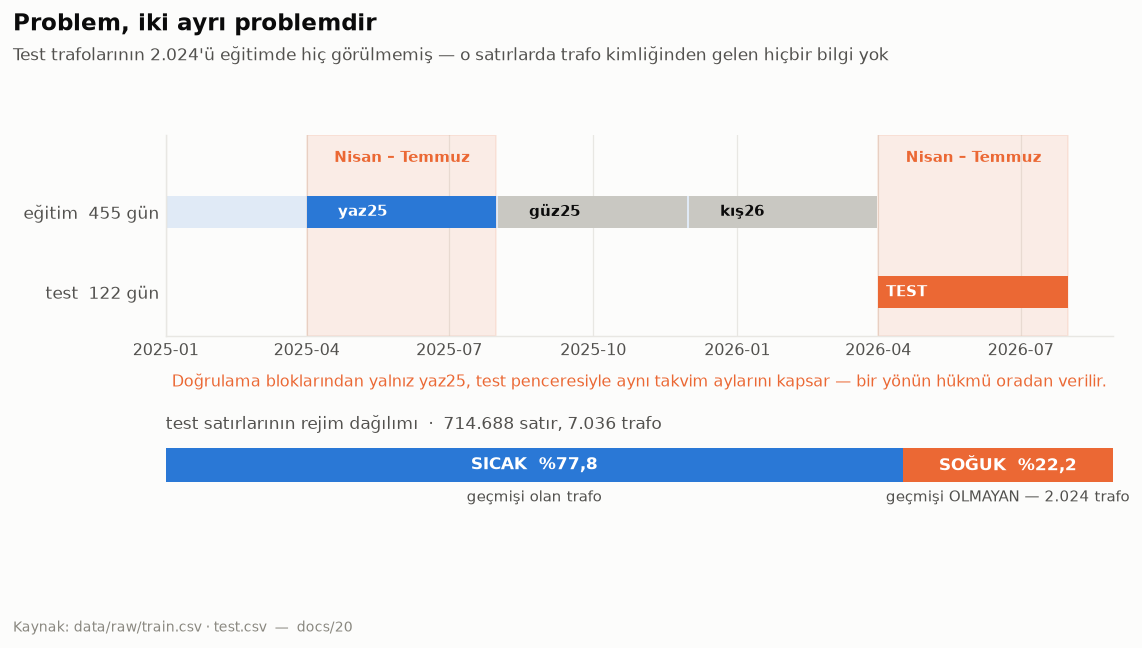

In [7]:
# Şekil 1 — veri geometrisi ve soğuk başlangıç
import matplotlib.dates as mdates

fig = plt.figure(figsize=(9.4, 3.9))
gs = fig.add_gridspec(2, 1, height_ratios=[1.45, 0.62], hspace=0.72)
a1, a2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
gun = lambda s: mdates.date2num(pd.Timestamp(s))

for yil in ("2025", "2026"):
    a1.axvspan(gun(yil + "-04-01"), gun(yil + "-07-31"), color=TURUNCU, alpha=0.10, zorder=1)
    a1.text(gun(yil + "-06-01"), 1.62, "Nisan – Temmuz", ha="center",
            fontsize=8.4, color=TURUNCU, fontweight="bold")
a1.barh(1, gun("2026-03-31") - gun("2025-01-01"), left=gun("2025-01-01"),
        height=0.40, color=MAVI, alpha=0.13, zorder=2)
for ad, b, s in [("yaz25", "2025-04-01", "2025-07-31"), ("güz25", "2025-08-01", "2025-11-30"),
                 ("kış26", "2025-12-01", "2026-03-31")]:
    ikiz = ad == "yaz25"
    a1.barh(1, gun(s) - gun(b), left=gun(b), height=0.40,
            color=MAVI if ikiz else "#c9c8c2", zorder=3)
    a1.text(gun(b) + 20, 1, ad, va="center", ha="left", fontsize=8.5,
            color="white" if ikiz else MUREKKEP, fontweight="bold", zorder=4)
a1.barh(0, gun("2026-07-31") - gun("2026-04-01"), left=gun("2026-04-01"),
        height=0.40, color=TURUNCU, zorder=3)
a1.text(gun("2026-04-06"), 0, "TEST", va="center", ha="left", fontsize=8.5,
        color="white", fontweight="bold", zorder=4)
a1.set_yticks([1, 0]); a1.set_yticklabels(["eğitim  455 gün", "test  122 gün"], fontsize=9.5)
a1.set_ylim(-0.55, 1.95)
a1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
a1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
temiz(a1, eksen="x")
a1.set_xlabel("Doğrulama bloklarından yalnız yaz25, test penceresiyle aynı takvim aylarını "
              "kapsar — bir yönün hükmü oradan verilir.",
              fontsize=8.6, color=TURUNCU, labelpad=8)

sol = 0
for p, c, ad in [(77.84, MAVI, "SICAK  %77,8"), (22.16, TURUNCU, "SOĞUK  %22,2")]:
    a2.barh(0, p, left=sol, height=0.62, color=c, zorder=3)
    a2.text(sol + p / 2, 0, ad, ha="center", va="center", fontsize=9.5,
            color="white", fontweight="bold", zorder=4)
    sol += p
a2.text(38.9, -0.66, "geçmişi olan trafo", ha="center", fontsize=8.5, color=IKINCIL)
a2.text(88.9, -0.66, "geçmişi OLMAYAN — 2.024 trafo", ha="center", fontsize=8.5, color=IKINCIL)
a2.set_xlim(0, 100); a2.set_ylim(-1.1, 0.45); a2.set_yticks([]); a2.set_xticks([])
for k in ("top", "right", "left", "bottom"):
    a2.spines[k].set_visible(False)
a2.set_title("test satırlarının rejim dağılımı  ·  714.688 satır, 7.036 trafo",
             fontsize=9.5, fontweight="normal", color=IKINCIL, loc="left", pad=6)
baslik(fig, "Problem, iki ayrı problemdir",
       "Test trafolarının 2.024'ü eğitimde hiç görülmemiş — o satırlarda trafo "
       "kimliğinden gelen hiçbir bilgi yok")
kaynak(fig, "Kaynak: data/raw/train.csv · test.csv  —  docs/20")
plt.show()

### 2.3 · Varyans ayrıştırması — sinyal nerede

`log1p(tuketim)` üzerinde, eğitim içi (`docs/20` §5):

| Tahmin | R² | Eğitim-içi RMSLE |
|---|---|---|
| Global ortalama | %0,0 | 2,1474 |
| İlçe ortalaması | %15,5 | 1,9739 |
| `guc` kovası (log1p, 20 kova) | %26,2 | 1,8454 |
| **Trafo seviyesi** | **%90,1** | **0,6772** |
| Trafo × haftagünü | %90,3 | 0,6676 |
| Trafo × ay | %95,4 | 0,4582 |

`guc` ↔ `tuketim` Spearman **0,6656**; `log1p` uzayında Pearson 0,4779.

Baskın sinyal trafonun kendi geçmişidir. Bu iyi haber değil — **sızıntıya en
yakın duran şey** de odur: bir trafonun ortalaması, o ortalamanın *içinde yer
alan* satır için hesaplanırsa model kendi cevabını okur. Bölüm 5 bu çizgiyi
nasıl koruduğumuzu anlatıyor.

In [8]:
# --------------------------------------------- varyans ayristirmasi (canli)
if VERI_VAR:
    y = np.log1p(train["tuketim"].to_numpy(dtype="float64"))
    tam_var = float(np.var(y))

    def r2_ve_rmsle(grup: pd.Series) -> tuple[float, float]:
        ort = pd.Series(y).groupby(grup.to_numpy()).transform("mean").to_numpy()
        return 1.0 - float(np.var(y - ort)) / tam_var, float(np.sqrt(np.mean((y - ort) ** 2)))

    guc_kova = pd.cut(np.log1p(train["guc"]), bins=20).astype(str)
    satirlar = []
    for ad, grup in [
        ("global ortalama", pd.Series(np.zeros(len(train)))),
        ("ilce ortalamasi", train["ilce_key"]),
        ("guc kovasi (20)", pd.Series(guc_kova)),
        ("TRAFO seviyesi", train["tanim"]),
        ("trafo x haftagunu", train["tanim"].astype(str) + "_" + train["tarih"].dt.dayofweek.astype(str)),
        ("trafo x ay", train["tanim"].astype(str) + "_" + train["tarih"].dt.month.astype(str)),
    ]:
        r2, rm = r2_ve_rmsle(grup)
        satirlar.append({"tahmin": ad, "R2": f"%{100 * r2:.1f}", "egitim-ici RMSLE": f"{rm:.4f}"})
    print(pd.DataFrame(satirlar).to_string(index=False))
    print()
    print(f"guc <-> tuketim Spearman : {train[['guc', 'tuketim']].corr(method='spearman').iloc[0, 1]:.4f}")
else:
    print("Yukaridaki markdown tablosu docs/20 §5'ten -- bu makinede olculmustu.")

           tahmin    R2 egitim-ici RMSLE
  global ortalama  %0.0           2.1474
  ilce ortalamasi %15.5           1.9739
  guc kovasi (20) %26.2           1.8454
   TRAFO seviyesi %90.1           0.6772
trafo x haftagunu %90.3           0.6676
       trafo x ay %95.4           0.4582



guc <-> tuketim Spearman : 0.6656


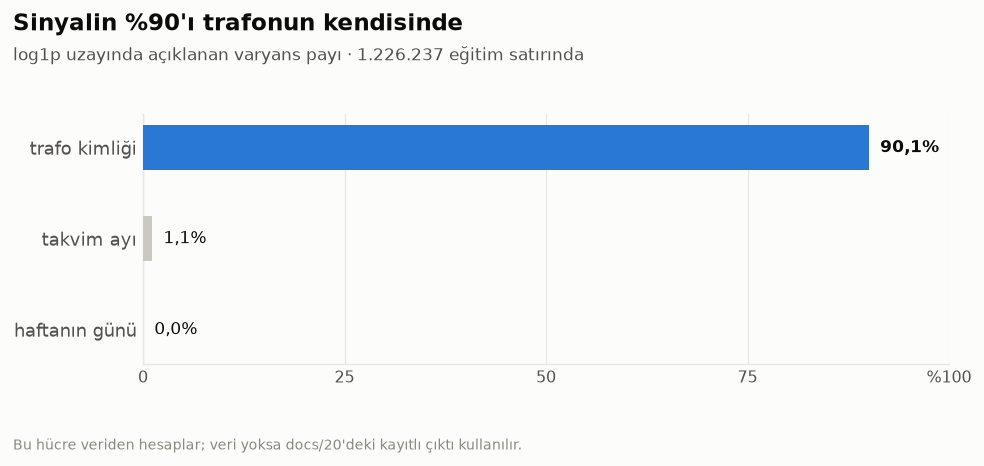

In [9]:
# Şekil 2 — sinyal nerede? (veri varsa hesaplanır, sabit yazılmamıştır)
if VERI_VAR:
    y = np.log1p(np.clip(train["tuketim"].to_numpy("float64"), 0, None))
    tam = float(y.var())
    ort = lambda anahtar: float((pd.DataFrame({"k": anahtar, "y": y})
                                 .groupby("k")["y"].transform("mean").to_numpy() - y).var())
    trafo = 100 * (1 - ort(train["tanim"].to_numpy()) / tam)
    ay = 100 * (1 - ort(train["tarih"].dt.month.to_numpy()) / tam)
    hg = 100 * (1 - ort(train["tarih"].dt.dayofweek.to_numpy()) / tam)
else:
    trafo, ay, hg = 90.1, 1.13, 0.01          # docs/20 — aynı hesabın kayıtlı çıktısı

fig, ax = plt.subplots(figsize=(8.0, 2.5))
val = [trafo, ay, hg]
ax.barh([2, 1, 0], val, height=0.5, color=[MAVI, "#c9c8c2", "#c9c8c2"], zorder=3)
for i, v in zip([2, 1, 0], val):
    ax.text(v + 1.4, i, ("%.1f" % v).replace(".", ",") + "%", va="center", fontsize=9.5,
            color=MUREKKEP, fontweight="bold" if v > 50 else "normal")
ax.set_yticks([2, 1, 0])
ax.set_yticklabels(["trafo kimliği", "takvim ayı", "haftanın günü"], fontsize=10)
ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "%100"])
temiz(ax, eksen="x")
baslik(fig, "Sinyalin %90'ı trafonun kendisinde",
       "log1p uzayında açıklanan varyans payı · 1.226.237 eğitim satırında")
kaynak(fig, "Bu hücre veriden hesaplar; veri yoksa docs/20'deki kayıtlı çıktı kullanılır.")
plt.show()

### 2.4 · Ufuk kısıtı — kısa gecikmeli öznitelikler YASAK

Test dönemi eğitimin bittiği günün **hemen ertesinde** başlıyor ve 122 gün
sürüyor. Yani test'in ilk günü için bile `lag-1`, `lag-7` gibi kısa gecikmeler
hesaplanamaz; son günü için 122 günlük bir boşluk vardır.

Kullanılabilir olanlar yalnızca:

* trafo bazlı **statik** özetler (özet penceresinin tamamından: seviye, yayılım,
  haftagünü profili, ay profili, `guc`'e göre normalize seviye),
* takvim (tatil, Ramazan, gün uzunluğu),
* **hava** — test döneminde gerçekleşmiş veri elimizde (bkz. Bölüm 3.4 beyanı).

Bu kısıt kod düzeyinde zorlanıyor: `gridup.features.temporal` içindeki
`add_lag_features` / `add_rolling_features` / `add_expanding_features`
fonksiyonlarının üçünde de `horizon` parametresi **varsayılansız**. Test bloğu
122 günlükse `horizon=1` yazmak 121 günlük bir sızıntıdır ve CV mükemmel
görünür.

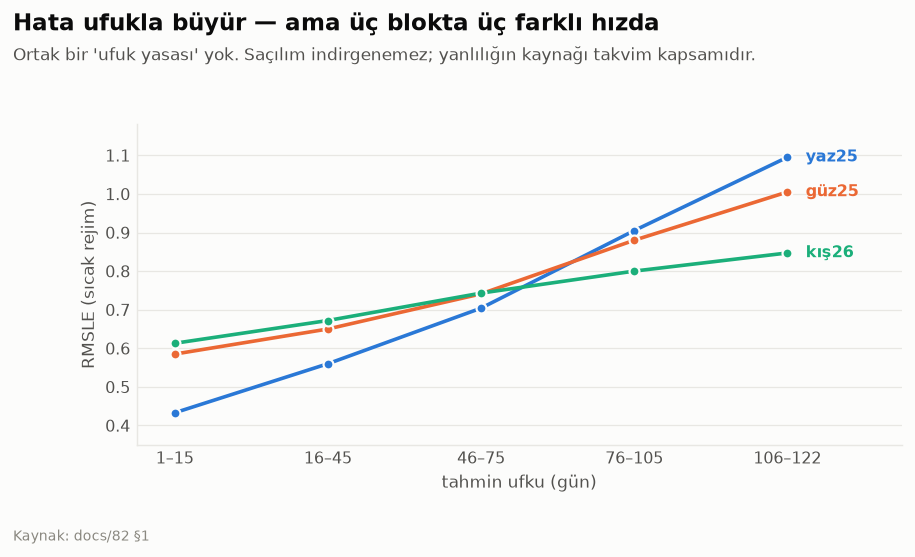

In [10]:
# Şekil 3 — ufuk etkisi (docs/82 §1, üretim harmanlı blok kurulumu)
ufuk = ["1–15", "16–45", "46–75", "76–105", "106–122"]
seri = {"yaz25": [0.433, 0.560, 0.704, 0.905, 1.095],
        "güz25": [0.585, 0.650, 0.741, 0.880, 1.005],
        "kış26": [0.613, 0.672, 0.743, 0.800, 0.847]}
fig, ax = plt.subplots(figsize=(7.6, 3.2))
for (ad, v), c in zip(seri.items(), [MAVI, TURUNCU, SU]):
    ax.plot(range(5), v, color=c, lw=2.0, marker="o", ms=5.5,
            markeredgecolor=ZEMIN, markeredgewidth=1.2, label=ad, zorder=3)
    ax.text(4.12, v[-1], ad, color=c, fontsize=9, va="center", fontweight="bold")
ax.set_xticks(range(5)); ax.set_xticklabels(ufuk, fontsize=9)
ax.set_xlim(-0.25, 4.75); ax.set_ylim(0.35, 1.18)
ax.set_xlabel("tahmin ufku (gün)", fontsize=9.5)
ax.set_ylabel("RMSLE (sıcak rejim)", fontsize=9.5)
temiz(ax)
baslik(fig, "Hata ufukla büyür — ama üç blokta üç farklı hızda",
       "Ortak bir 'ufuk yasası' yok. Saçılım indirgenemez; yanlılığın kaynağı takvim kapsamıdır.")
kaynak(fig, "Kaynak: docs/82 §1")
plt.show()

<a id="3"></a>
# 3 · DIŞ VERİ BEYANI

> **Yarışma yükümlülüğü.** Düzenleyici, forumda (topic 737615, 2026-08-27) ve
> ardından doğrudan e-postayla (2026-08-29) dış kaynak kullanımının **serbest**
> olduğunu, tek koşulun **notebook'ta hangi kaynağın hangi amaçla ve nasıl
> kullanıldığının beyan edilmesi** olduğunu bildirdi. Kayıt:
> `experiments/model29/k2_veri_kurali.json`.

Bu bölüm o yükümlülüğü karşılar. Aşağıda **üç tablo** vardır:

* **Tablo A** — üretim modeline **gerçekten giren** kaynaklar,
* **Tablo B** — depoda bulunan ama modele **girmeyen** kaynaklar (neden girmediği
  yazılıdır; bazıları ölçülüp reddedildi, biri **kasıtlı olarak dışlandı**),
* **Tablo C** — kod içinde üretilen takvim kaynakları.

Her kaynağın lisansı, atfı ve SHA-256 parmak izi `data/sources.yml` içinde
kayıtlıdır ve aşağıdaki bir hücre bunu doğrudan okuyup basar.

### 3.1 · Tablo A — üretim modeline GİREN dış kaynaklar

| # | Kaynak | Lisans / Atıf | Amaç | Modelde nasıl kullanıldı |
|---|---|---|---|---|
| A1 | **Open-Meteo ERA5 arşivi — günlük hava**<br>`archive-api.open-meteo.com/v1/archive`<br>`data/external/hava_gunluk.parquet` | CC BY 4.0 — "Weather data by Open-Meteo.com" | Klima yükü sürücüsü | 96 ilçe × gün. `sicaklik_ort/max/min`, `hissedilen_max`, `yagis_toplam`, `yagis_saati`, `ruzgar_max`, `gunes_radyasyon`, `asiri_sicak`, `asiri_soguk` kolonları `ilce_key`+`tarih` ile join edilir. Üzerine **CDD** (soğutma derece-gün) taban 18/22/24 ile yeniden hesaplanır ve `cdd22`, `cdd24`, `sicaklik_ort` için 3/7/14 günlük **ısıl atalet** hareketli ortalamaları türetilir. |
| A2 | **Open-Meteo — nem & toprak**<br>`data/external/nem_toprak_gunluk.parquet` | CC BY 4.0 — Open-Meteo | Hissedilen sıcaklık + tarımsal/sulama yükü | `nem_ort`, `ciy_ort`, `vpd_ort`, `toprak_nem_ort`, `bulut_dusuk_ort`, `et0_toplam` aynı `ilce_key`+`tarih` anahtarıyla eklenir. Toprak nemi ve ET0, Ege'de yaz aylarındaki **sulama pompası yükü** için fiziksel vekildir. |
| A3 | **Güneş geometrisi (kendi türetimimiz)**<br>`data/external/gunes_gunluk.parquet` | MIT (bu depo) — pvlib (BSD-3-Clause) ile hesaplandı | Aydınlatma yükü + açık-hava ışınımı | İlçe koordinatlarından `pvlib` ile deterministik hesap; hedefe hiç dokunmaz, dolayısıyla sızıntı riski yok. `gunes_ghi_gunluk` ve `gun_uzunlugu_saat` kolonları kullanılır. |
| A4 | **ESA WorldCover 10 m 2021 v200 — arazi örtüsü**<br>`data/external/arazi_ortusu_ilce.parquet` | CC BY 4.0 — © ESA WorldCover project / modified Copernicus Sentinel data (2021); Zanaga et al., doi:10.5281/zenodo.7254221 | İlçeyi çıplak etiketten **vektöre** çevirmek | İlçe merkezli alan-eşdeğer daire (r = √(alan/π), 3–25 km) içinde 100 m örnekleme ile 8 oran: `agac_orani`, `calilik_orani`, `otlak_orani`, `tarim_orani`, `yerlesim_orani`, `ciplak_orani`, `su_orani`, `bitki_ortusu_orani`. **Soğuk trafolar için kritik:** model daha önce hiç görmediği bir ilçeye bile genelleyebilir, çünkü ilçe 47 seviyeli bir kategorik değil sürekli bir vektör. |
| A5 | **OpenStreetMap — şebeke altyapısı** (Overpass API, `power=*`)<br>`data/external/osm_altyapi_ilce.parquet` | **ODbL 1.0** — © OpenStreetMap contributors. Türetilmiş veritabanı aynı lisansla paylaşılır. | Şebeke yoğunluğu = abone yoğunluğu vekili | Aynı alan-eşdeğer daire içinde: `osm_trafo`, `osm_direk`, `osm_dagitim_hat_km`, `osm_iletim_hat_km`, `osm_kablo_km`, `osm_direk_yogunlugu`, `osm_hat_yogunlugu`. Ayrıca `trafo_basina_hat = osm_dagitim_hat_km / ilce_trafo_sayisi` türetilir. Gerekçe: aynı kVA'lık bir trafo seyrek kırsal bir ağda ile yoğun kentsel bir ağda farklı yük taşır. |
| A6 | **İlçe referans tablosu**<br>`turkiyeapi.dev/api/v1/districts` + Open-Meteo geocoding<br>`data/reference/ilceler_gdz_adm.{parquet,csv}` | MIT (ubeydeozdmr/turkiye-api) + CC BY 4.0 (Open-Meteo) | Join anahtarı, koordinat, nüfus | 96 GDZ+ADM ilçesi: `il`, `ilce`, `lat`, `lon`, `nufus`, `alan_km2`. **Koordinatlar** tüm hava/güneş çekimlerinin girdisidir. **Nüfus** `ilce_nufus_yogunlugu`, `trafo_basina_nufus`, `kva_basina_nufus` kolonlarını üretir — ancak bu 5 kolon nihai öznitelik setinden **budanmıştır** (Bölüm 4.3; ölçüldü, artıkla korelasyon 0,038). |
| A7 | **EPİAŞ Şeffaflık Platformu — Türkiye ulusal saatlik tüketim**<br>`data/external/epias/tuketim_saatlik.parquet` | EPİAŞ Şeffaflık Platformu (kamuya açık; yeniden dağıtım `restricted` işaretlidir, Kaggle paketine konmaz) | Ülke çapındaki günlük talep rejimini yakalamak | Saatlik seri günlüğe indirgenir: `ulusal_gunluk` (toplam MWh), `ulusal_tepe`, `ulusal_tepe_orani` (tepe/ortalama = gün içi yayılma), `ulusal_yil_once` (364 gün önceki aynı haftagünü), `ulusal_yillik_buyume` (log oran, mevsimden arındırılmış büyüme). **Bu bir gözlemdir, tahmin değildir** ve test dönemini kapsar. |

### 3.2 · Tablo B — depoda bulunan, modele GİRMEYEN kaynaklar

Bu kaynakların hepsi ya **ölçülüp reddedildi** ya da **kasıtlı olarak
dışlandı**. Beyanın tam olması için listeleniyorlar.

| # | Kaynak | Lisans / Atıf | Neden modele girmedi |
|---|---|---|---|
| B1 | **EPİAŞ Şeffaflık — plansız kesinti kayıtları**<br>`epias/kesinti_plansiz.parquet`, `epias/panel_ilce_gun.parquet`, `epias/panel_ilce_gun_tam.parquet` | EPİAŞ Şeffaflık Platformu (`redistribution: restricted`) | **KASITLI DIŞLAMA.** `data/sources.yml` içinde `model_girdisi: false` bayrağıyla işaretli ve bu bayrak kod düzeyinde `gridup.uygunluk` tarafından zorlanır (`tests/test_uygunluk_kapisi.py`). Gerekçe: Coderspace'in GDZ'22 Case-1 kural sayfası, kardeş problemin sonuç verilerinin model girdisi olmasını açıkça yasaklıyordu. Bu tablolar yalnızca **prova zemini** olarak (hattı gerçek veriyle sınamak) kullanıldı. |
| B2 | EPİAŞ Şeffaflık — Türkiye saatlik **üretim** (yakıt kırılımlı)<br>`epias/uretim_saatlik.parquet` | EPİAŞ Şeffaflık Platformu | Çekildi, üretim modelinde kullanılmadı. |
| B3 | Open-Meteo — saatlik türevler (basınç düşüşü, rüzgâr kuantilleri, yön sin/cos)<br>`hava_saatlik_turev.parquet` | CC BY 4.0 — Open-Meteo | **Kesinti** fiziği için çekilmişti. Tüketimle fiziksel bağlantısı yok; ölçülmeden eklemek "her şey feature'dır" hatası olurdu. `tuketim_model.py` içinde bu karar yorumla gerekçelendirilmiştir. |
| B4 | Open-Meteo Air Quality (CAMS) — PM10 / PM2.5 / toz<br>`hava_kalitesi_gunluk.parquet` | CC BY 4.0 — Open-Meteo | Aynı gerekçe (B3). |
| B5 | Open-Meteo Historical Forecast — konvektif (CAPE / lifted index / CIN)<br>`konvektif_gunluk.parquet` | CC BY 4.0 — Open-Meteo | Aynı gerekçe (B3). Ayrıca arşiv 2021-05'te başlıyor. |
| B6 | **AFAD** deprem kataloğu (+ USGS FDSN yedeği)<br>`depremler.parquet` | AFAD kurumsal izin; USGS verisi ABD kamu malı | Kesinti çalışması için çekildi; tüketim modeline girmedi. |
| B7 | **NASA LANCE FIRMS** aktif yangın (MODIS/VIIRS)<br>`yanginlar.parquet` | NASA EOSDIS açık veri politikası — "We acknowledge the use of data from NASA LANCE FIRMS, part of NASA's ESDIS" | Kesinti çalışması için çekildi; tüketim modeline girmedi. |
| B8 | **T.C. Kültür ve Turizm Bakanlığı (YİGM)** — yıllık konaklama istatistikleri<br>`turizm_geceleme.parquet` | KTB kurumsal izin | Turizm sinyali ilçe düzeyinde denendi, üretim setine alınmadı. |
| B9 | **KTB YİGM** — aylık konaklama istatistikleri (2019-01…2026-06, 90 xlsx + 46 belediye xlsx)<br>`turizm_aylik_il.parquet` | KTB kurumsal izin | Aynı (B8). İl düzeyinde aylık; ilçe granülaritesine inmiyor. |
| B10 | **İZSU / İzmir BB Açık Veri** — ilçe-mahalle su tüketimi<br>`izsu_su_profili.parquet` | CC BY 4.0 (İzmir BB Açık Veri Lisansı) | Yaz/kış nüfus hareketi vekili olarak denendi; 2024-09'da bitiyor ve yalnız İzmir'i kapsıyor. Üretime alınmadı. |
| B11 | **GDZ Elektrik lisanssız üretim teknik değerlendirme arşivi** (170 PDF)<br>`lisanssiz_ges.parquet` | GDZ Elektrik kurumsal yayın (kamuya açık ajax ucu) | **Ölçüldü ve reddedildi** (`docs/30` §): AG bağlantılı onaylı çatı-GES kapasitesi 2019–2021'de tamamlanmış; bizim pencerede (2025-04 → 2026-07) yıllık ilave 0,3 MW — gürültü seviyesinde. Ayrıca arşiv yapısal olarak yalnız 25 kW üstü başvuruları içeriyor. |
| B12 | Kaggle `tmlalper/manisa-izmir-plansiz-elektrik-kesintileri` (68.257 kayıt)<br>`data/prior/ayna/` | Kaggle'da halka açık | **Yarışma verisi gelmeden önceki** prova zemini. Farklı bir hedefe (kesinti dakikası) ait; tüketim modeline girmedi. |
| B13 | **MEB okul takvimi 2021–2026** (kod içi, `gridup.features.school`) | MEB resmî çalışma takvimleri + duyuruları | Kod içinde mevcut ve doğrulanmış (6 ders yılı), ancak üretim tüketim modelinin takvim hattına bağlanmadı. |

### 3.3 · Tablo C — kod içinde üretilen takvim kaynakları

Bu üç aile dışarıdan **dosya olarak** indirilmez; kod içinde deterministik
üretilir. Üretim modelinde **hesaplanır ama nihai öznitelik setinden budanır**
(Bölüm 4.3) — yine de beyanın tam olması için listeleniyorlar.

| # | Kaynak | Nasıl üretiliyor | Durum |
|---|---|---|---|
| C1 | **Türkiye resmî tatilleri** | `holidays` kütüphanesi + `gridup.features.temporal.add_turkish_holiday_features` | Hesaplanıyor, budanıyor |
| C2 | **İdari izin günleri** (bayram öncesi/sonrası ek tatil) | Elle kodlanmış `ADMINISTRATIVE_LEAVE` tablosu. Kaynak: Cumhurbaşkanlığı İdari İşler Başkanlığı Personel ve Prensipler Genel Müdürlüğü yazısı / İletişim Başkanlığı–AA duyurusu. `holidays` kütüphanesinde **yoktur** ama kamu ve okullar kapanır. | Hesaplanıyor, budanıyor |
| C3 | **Ramazan takvimi** | `hijridate` (Umm al-Qura) ile hicri→miladi dönüşüm. Doğrulandı: `frtgnn/turkish-calendar` veri setinin `RAMADAN_FLAG` kolonuyla 2020–2024 arası **birebir** örtüşüyor, 2023'ün 29 günlük Ramazanı dahil. 1447 AH = 2026-02-18 → 2026-03-19. | Hesaplanıyor, budanıyor |

### 3.4 · Açık beyanlar

**(a) Nisan–Temmuz 2026 GERÇEKLEŞMİŞ hava verisi kullanıldı.** Test döneminin
hava verisi bizde tahmin olarak değil, **gerçekleşmiş ERA5 arşiv verisi** olarak
bulunuyor ve modele bu haliyle girdi. Düzenleyicinin forum mesajı (topic 737615,
2026-08-26) gerçekleşmiş ve tahminlenmiş hava verisini *seçeneklerden biri*
olarak sayıp hangisinin kullanıldığının açıklanmasını istiyordu; 2026-08-27
mesajı ve 2026-08-29 e-postası dış kaynak kullanımını serbest bıraktı. Beyanımız
budur: **gerçekleşmiş hava verisi kullanıldı.**

**(b) Yarışma hedefinin geçmişi modele girmedi.** EPİAŞ plansız kesinti kayıtları
(B1) `model_girdisi: false` bayrağıyla işaretli ve bu bayrak testle zorlanıyor.

**(c) `ulusal_*` kolonları test dönemini kapsar.** EPİAŞ ulusal saatlik tüketim
(A7) bir *gözlemdir*, tahmin değil — ve test penceresini içerir. Bu, hava
verisiyle aynı sınıfta bir kullanımdır ve aynı beyana tabidir.

**(d) Lisans yükümlülükleri.** OSM türevleri **ODbL 1.0 share-alike** altındadır;
Open-Meteo, ESA WorldCover ve İZSU türevleri **CC BY 4.0** atıf gerektirir; AFAD
ve KTB kaynakları **yayımlanmış açık lisans değil, kurumdan alınmış yazılı
izindir** ve bir denetçi bunları SPDX tanımlı bir hak devri olarak değil,
belgelenmiş izin olarak okumalıdır.

In [11]:
# ============================================================================
# DIS VERI KUNYESI -- data/sources.yml dosyasindan DOGRUDAN okunur.
# Her artifact icin: lisans, atif, yeniden dagitim, kaynak URI, SHA-256.
# ============================================================================
kaynak_yolu = KOK / "data" / "sources.yml"

if kaynak_yolu.exists():
    kunye = json.loads(kaynak_yolu.read_text(encoding="utf-8"))
    satirlar = []
    for a in kunye["artifacts"]:
        satirlar.append(
            {
                "dosya": a["path"].replace("data/", ""),
                "lisans": a["license"],
                "yeniden_dagitim": a["redistribution"],
                "model_girdisi": a.get("model_girdisi", True),
                "kaynak": a["source"]["uri"][:52],
                "sha256": a["sha256"][:12] + "...",
            }
        )
    df_kunye = pd.DataFrame(satirlar)
    print(f"data/sources.yml -- {len(df_kunye)} kayitli artifact\n")
    print(df_kunye.to_string(index=False))
    print()
    print("Lisans dagilimi:")
    print(df_kunye["lisans"].value_counts().to_string())
    print()
    print("MODEL GIRDISI OLMAYAN (kasitli dislama, kod duzeyinde zorlaniyor):")
    for a in kunye["artifacts"]:
        if a.get("model_girdisi") is False:
            print(f"  - {a['path']}")
            print(f"      gerekce: {a['model_girdisi_gerekce'][:150]}...")
else:
    print("data/sources.yml bu ortamda yok. Beyan tablolari (3.1-3.3) yukaridadir.")

data/sources.yml -- 20 kayitli artifact

                                    dosya                       lisans yeniden_dagitim  model_girdisi                                               kaynak          sha256
             external/hava_gunluk.parquet                    CC-BY-4.0         allowed           True        https://archive-api.open-meteo.com/v1/archive 452f299362fd...
            external/gunes_gunluk.parquet                          MIT         allowed           True local-derived:pvlib+data/reference/ilceler_gdz_adm.p 5a0b0c961cef...
        reference/ilceler_gdz_adm.parquet                          MIT         allowed           True              https://turkiyeapi.dev/api/v1/districts 2abd70cb16ca...
            reference/ilceler_gdz_adm.csv                          MIT         allowed           True local-derived:data/reference/ilceler_gdz_adm.parquet 6d9f56edc92c...
      external/hava_saatlik_turev.parquet                    CC-BY-4.0         allowed           True   

In [12]:
# ============================================================================
# DIS VERI BAGLANTI DOGRULAMASI -- 47/47 ilce eslesmesi
# Turkce 'I' tuzagi yuzunden bu kontrol atlanirsa join SESSIZCE sifira duser.
# ============================================================================
if VERI_VAR and DIS_VAR:
    ilceler = set(pd.concat([train["ilce_key"], test["ilce_key"]]).unique())
    kontroller = [
        ("hava_gunluk.parquet", DIS / "hava_gunluk.parquet"),
        ("nem_toprak_gunluk.parquet", DIS / "nem_toprak_gunluk.parquet"),
        ("arazi_ortusu_ilce.parquet", DIS / "arazi_ortusu_ilce.parquet"),
        ("osm_altyapi_ilce.parquet", DIS / "osm_altyapi_ilce.parquet"),
    ]
    sonuc = []
    for ad, yol in kontroller:
        if not yol.exists():
            sonuc.append({"tablo": ad, "durum": "DOSYA YOK"})
            continue
        d = pd.read_parquet(yol, columns=["ilce_key"])
        tablo_ilce = set(d["ilce_key"].unique())
        eslesen = len(ilceler & tablo_ilce)
        sonuc.append(
            {"tablo": ad, "tablo_ilce": len(tablo_ilce),
             "eslesen": f"{eslesen}/{len(ilceler)}",
             "durum": "TAM" if eslesen == len(ilceler) else "EKSIK"}
        )
    print(pd.DataFrame(sonuc).to_string(index=False))
    print()
    print("Kayitli olcum (docs/20 §2): yedi dis tabloda da 47/47, hicbir kurtarma katmani gerekmedi.")
else:
    print("docs/20 §2 kayitli olcumu -- 47/47 eslesme:")
    for t in ["hava_gunluk", "nem_toprak_gunluk", "hava_saatlik_turev", "hava_kalitesi_gunluk",
              "konvektif_gunluk", "arazi_ortusu_ilce", "osm_altyapi_ilce"]:
        print(f"  {t:26} 47/47")

                    tablo  tablo_ilce eslesen durum
      hava_gunluk.parquet          96   47/47   TAM
nem_toprak_gunluk.parquet          96   47/47   TAM
arazi_ortusu_ilce.parquet          96   47/47   TAM
 osm_altyapi_ilce.parquet          96   47/47   TAM

Kayitli olcum (docs/20 §2): yedi dis tabloda da 47/47, hicbir kurtarma katmani gerekmedi.


<a id="4"></a>
## 4 · Öznitelik mühendisliği

Üretim çerçevesi **4.148.269 satır × 157 kolon** (~4,65 GB) olarak kurulur
(`docs/34`). Bunun 151'i sayısal/kategorik öznitelik adayıdır; nihai model
**105 kolon** kullanır. Budamanın gerekçesi 4.3'te ölçümle birlikte veriliyor.

### 4.1 · Öznitelik aileleri

In [13]:
aileler = pd.DataFrame(
    [
        ("t_*", "Trafo geçmiş özetleri", 20,
         "t_log_ort/std/medyan/p10/p90, t_yayilma, t_gun_sayisi, t_sifir_orani, t_yuk_faktoru, "
         "t_trend, t_kuyruk_sifir, t_olu_mu, t_son_kayit_yasi, t_kayma, t_hg_genligi, "
         "t_log_son7..son90 (guncellik), t_gy_* (gecen yilin ayni donemi)",
         "yarisma verisi"),
        ("hava (A1)", "Gunluk hava + isil atalet", 22,
         "sicaklik_ort/max/min, hissedilen_max, yagis_toplam, yagis_saati, ruzgar_max, "
         "gunes_radyasyon, asiri_sicak/soguk, cdd18/22/24, cdd22_ort3/7/14, cdd24_ort3/7/14, "
         "sicaklik_ort_ort3/7/14", "Open-Meteo ERA5"),
        ("nem/toprak (A2)", "Nem, cig, VPD, toprak nemi", 6,
         "nem_ort, ciy_ort, vpd_ort, toprak_nem_ort, bulut_dusuk_ort, et0_toplam", "Open-Meteo"),
        ("gunes (A3)", "Gunes geometrisi", 2, "gunes_ghi_gunluk, gun_uzunlugu_saat", "pvlib (kendi turetimimiz)"),
        ("arazi (A4)", "Arazi ortusu oranlari", 8,
         "agac/calilik/otlak/tarim/yerlesim/ciplak/su/bitki_ortusu_orani", "ESA WorldCover 2021"),
        ("osm_* (A5)", "Sebeke altyapisi", 8,
         "osm_trafo, osm_direk, osm_dagitim_hat_km, osm_iletim_hat_km, osm_kablo_km, "
         "osm_direk_yogunlugu, osm_hat_yogunlugu, trafo_basina_hat", "OpenStreetMap (ODbL)"),
        ("ilce yapisi", "Trafonun ilcesindeki kapasite konumu", 6,
         "ilce_trafo_sayisi, ilce_toplam_guc, ilce_guc_medyan, guc_yuzdelik, guc_payi, guc_medyan_orani",
         "yarisma verisi (varlik listesi)"),
        ("nufus (A6)", "Nufus turevleri -- BUDANDI", 5,
         "nufus, alan_km2, ilce_nufus_yogunlugu, trafo_basina_nufus, kva_basina_nufus",
         "turkiye-api (MIT)"),
        ("ulusal_* (A7)", "Turkiye gunluk talep rejimi", 5,
         "ulusal_gunluk, ulusal_tepe, ulusal_tepe_orani, ulusal_yil_once, ulusal_yillik_buyume",
         "EPIAS Seffaflik"),
        ("tk_/tatil/ramazan (C)", "Takvim -- BUDANDI", 20,
         "tk_ay, tk_haftagunu, tk_yilin_gunu, tk_haftasonu, tatil_mi, tatil_agirligi, "
         "tatil_kod, ramazan_mi, ramazan_gunu, bayram_arifesi ...", "holidays + hijridate"),
        ("p_* (panel)", "Panel yapisi -- BUDANDI", 6,
         "p_ozet_pencere_gun, p_doluluk, p_kapsam ...", "yarisma verisi"),
        ("g_/gp_* (grup)", "Grup seviye ve profilleri -- BUDANDI", 12,
         "g_ilce_seviye, g_kova_seviye, gp_ilce_ay, gp_kova_ay ...", "yarisma verisi"),
        ("kimlik / yas", "tanim numarasindan statik turevler + trafo yasi", 6,
         "kimlik_blok, kimlik_komsu, yas_gun, ilk_kayit_yasi ...", "yarisma verisi"),
        ("kategorik", "Konum kategorikleri", 3, "il_key, bolge, ilce_key", "yarisma verisi"),
    ],
    columns=["aile", "ne", "kolon~", "ornek kolonlar", "kaynak"],
)
print(aileler[["aile", "ne", "kolon~", "kaynak"]].to_string(index=False))
print()
print("NOT: 'kolon~' sutunu her ailenin ANA kolonlarini sayar, tam sayim degildir.")
print("     Kesin sayilar uretim kosusunun kendi ciktisindan gelir:")
print("       uretim cercevesi        4.148.269 satir x 157 kolon   (docs/34)")
print("       oznitelik adaylari      151 kolon")
print("       YALIN budamadan sonra   105 kolon  <- modelin gordugu set")
print("     Budanan aileler yukarida '-- BUDANDI' ile isaretli (bkz. 4.3).")

                 aile                                              ne  kolon~                          kaynak
                  t_*                           Trafo geçmiş özetleri      20                  yarisma verisi
            hava (A1)                       Gunluk hava + isil atalet      22                 Open-Meteo ERA5
      nem/toprak (A2)                      Nem, cig, VPD, toprak nemi       6                      Open-Meteo
           gunes (A3)                                Gunes geometrisi       2       pvlib (kendi turetimimiz)
           arazi (A4)                           Arazi ortusu oranlari       8             ESA WorldCover 2021
           osm_* (A5)                                Sebeke altyapisi       8            OpenStreetMap (ODbL)
          ilce yapisi            Trafonun ilcesindeki kapasite konumu       6 yarisma verisi (varlik listesi)
           nufus (A6)                      Nufus turevleri -- BUDANDI       5               turkiye-api (MIT)
        ul

### 4.2 · Sızıntı duvarı: `t_*` özetleri nasıl güvenli tutuluyor

Trafo özetleri **hedefi okur**. Bir satırın özeti kendi değerini içeriyorsa
model cevabı kopyalar. `gridup.features.trafo` bu çizgiyi tek işi olarak korur:

* Özetler `uydur` çerçevesinden **çıkar**, `uygula` çerçevesine **taşınır**.
* İki çerçeve asla aynı olamaz — fonksiyon bunu **kendisi denetler** ve
  ihlalde `RuntimeError` fırlatır.
* Soğuk trafolarda tüm `t_*` kolonları **NaN** olur ve bu doğru davranıştır:
  0 yazmak "tüketim sıfır", ortalama yazmak "ortalama bir trafo" demektir —
  ikisi de uydurmadır. LightGBM/CatBoost NaN'ı ayrı bir dal yönü olarak öğrenir.
* Ayrıca `soguk_mu` bayrağı **açıkça** üretilir: model "özet yok" durumunu tek
  kolondan görebilsin.

Bu, deponun dört tasarım sözleşmesinden ikisidir ve testlerle zorlanır:
22 öznitelik fonksiyonunun tamamı girdiyi değiştirmez, yeni frame döndürür,
satır sayısını *ve sırasını* korur; hedefe dokunan 33 fonksiyondan 12'si `folds`
alır, 21'inin neden güvenli olduğu yazılıdır.

In [14]:
# --------------------------------------- t_* ozetleri: sizinti duvari demosu
def trafo_ozeti_cikar(uydur: pd.DataFrame) -> pd.DataFrame:
    """OZET PENCERESINDEN cikarilan trafo seviyesi. Hedefi okur -- bu yuzden
    ciktisi YALNIZCA farkli bir (etiket) cerceveye uygulanabilir."""
    y = np.log1p(uydur["tuketim"].to_numpy(dtype="float64"))
    g = uydur.assign(_y=y).groupby("tanim", observed=True)["_y"]
    return pd.DataFrame(
        {"t_log_ort": g.mean(), "t_log_std": g.std(ddof=0),
         "t_log_p10": g.quantile(0.10), "t_log_p90": g.quantile(0.90),
         "t_gun_sayisi": g.size().astype("float64")}
    ).assign(t_yayilma=lambda d: d["t_log_p90"] - d["t_log_p10"])


def ozet_uygula(etiket: pd.DataFrame, ozet: pd.DataFrame) -> pd.DataFrame:
    """Ozeti etiket cercevesine tasir ve PENCERE KESISIMINI denetler."""
    yeni = etiket.merge(ozet, left_on="tanim", right_index=True, how="left")
    yeni["soguk_mu"] = yeni["t_log_ort"].isna().astype("int8")
    return yeni


if VERI_VAR:
    # yaz25 blogu: ozet 2025-01-01..03-31, etiket 2025-04-01..07-31 (KESISMEZ)
    ozet_pencere = train[train["tarih"] <= "2025-03-31"]
    etiket_pencere = train[(train["tarih"] >= "2025-04-01") & (train["tarih"] <= "2025-07-31")]

    assert ozet_pencere["tarih"].max() < etiket_pencere["tarih"].min(), "SIZINTI: pencereler kesisiyor"

    ozet = trafo_ozeti_cikar(ozet_pencere)
    blok = ozet_uygula(etiket_pencere, ozet)

    print(f"ozet penceresi   {ozet_pencere['tarih'].min().date()} .. {ozet_pencere['tarih'].max().date()}"
          f"  ({len(ozet_pencere):,} satir, {len(ozet):,} trafo)")
    print(f"etiket penceresi {etiket_pencere['tarih'].min().date()} .. {etiket_pencere['tarih'].max().date()}"
          f"  ({len(etiket_pencere):,} satir)")
    print(f"KESISIM          YOK  -- sizinti kapisi GECTI")
    print()
    print(f"bu blokta soguk satir payi: %{100 * blok['soguk_mu'].mean():.1f}"
          f"   (TEST'te %22,2 -- blok kendi payini tasir, bkz. Bolum 5)")
    print()
    print(blok[["tanim", "guc", "t_log_ort", "t_yayilma", "t_gun_sayisi", "soguk_mu"]].head(8).to_string(index=False))
else:
    print("Veri yok -- sizinti kapisi demosu atlandi.")

ozet penceresi   2025-01-01 .. 2025-03-31  (187,500 satir, 2,270 trafo)
etiket penceresi 2025-04-01 .. 2025-07-31  (274,929 satir)
KESISIM          YOK  -- sizinti kapisi GECTI

bu blokta soguk satir payi: %7.5   (TEST'te %22,2 -- blok kendi payini tasir, bkz. Bolum 5)

    tanim  guc  t_log_ort  t_yayilma  t_gun_sayisi  soguk_mu
 70122340 1000   8.546172   0.332872          90.0         0
 70142184 1250   6.376997   0.130660          90.0         0
700074584 1250   8.779403   0.475553          90.0         0
700096060 1250   9.082390   0.263703          90.0         0
700096062  400   3.786691   0.519231          90.0         0
700096063 1000   8.403425   0.231759          90.0         0
700096065 1000   8.294769   0.279756          90.0         0
700096067 1250   8.098209   0.812329          90.0         0


### 4.3 · Neden 151 değil 105 kolon — "yalın set"

En büyük tek kazanç bir öznitelik **eklemekten** değil, 46 kolon
**atmaktan** geldi. Ölçüldü (2026-08-22 gecesi, `docs/26` §5):

```
yalin set (105 kolon) + soguk uzmani depth=7 + sicak uzmani random_strength=4
BIRLIKTE:   1,08143  ->  1,05194     (-0,0295, esik 0,01995)

beklenen toplam (parcalarin ayri ayri olculmus kazanci)   0,017
gerceklesen                                               0,0295   <- SUPER-TOPLAMSAL
   sicak  0,7979 -> 0,7962   (-0,002, hicbir sey)
   soguk  1,7404 -> 1,6576   (-0,083)
```

**Kazancın tamamı soğuk taraftadır.** Mekanizma: soğuk uzmanı geçmiş görmüyor;
elinde kalan kolonların çoğu ilçe düzeyinde hava/takvim — yani trafoları
birbirinden **ayırmayan** kolonlar. 39 gürültü kolonunu atmak kıt sinyali
yoğunlaştırıyor, derinlik 7 de onu kullanabilmesini sağlıyor. Tek başına ne
budama ne derinlik yetiyor; ikisi birlikte açıyor.

**Budanan aileler:** `tk_` (takvim), `tatil`, `ramazan`, `p_` (panel yapısı),
`g_`/`gp_` (grup seviye/profil), `nufus` ailesi (5 kolon), `t_mevsim_`.

> **Kalıcı ders — `gp_ilce_ay` yangını.** `p_`/`g_`/`gp_` ailesinden 10 kolon
> geri verildiğinde ölçüm +0,0102 / t=+3,59 ve üç blokta da pozitif verdi.
> Sonra iki kolonun **yapısal olarak çarpık** olduğu bulundu: `gp_ilce_ay` ve
> `gp_kova_ay` eğitimde yalnız Ocak–Mart satırlarında doluydu, **testte %100
> doluydu** ve aylar Nisan–Temmuz'du. Test satırlarının %26'sı eğitim
> maksimumunun üstündeydi, Temmuz'un tamamı destek dışıydı. O iki kolon
> çıkarılıp kalan 8'i tek başına ölçülünce fark +0,00256 / t=+0,76'ya düştü,
> yani t=3,59'un tamamı çarpık kolonlardan geliyormuş. **Hüküm: her iki uzman
> da ek kolon almaz.** Ders: bir kolonun *doluluk deseni* eğitim ile test
> arasında farklıysa, kolonun kendisi değil o desen öğreniliyor olabilir — ve
> doğrulama bunu göremez.

<a id="5"></a>
## 5 · Doğrulama stratejisi — ileri-zaman blok CV

Rastgele K-fold bu problemde **anlamsızdır**: aynı trafonun geleceği eğitimde,
geçmişi doğrulamada olurdu. Bunun yerine **yuvarlanan köken (rolling origin)**
kurgusu kullanılıyor — her blokta özet penceresi etiket penceresinden **önce**
biter:

| blok | özet penceresi | etiket penceresi | gün | özet uzunluğu |
|---|---|---|---|---|
| `yaz25` | 2025-01-01 … 2025-03-31 | 2025-04-01 … 2025-07-31 | 122 | 90 |
| `guz25` | 2025-01-01 … 2025-07-31 | 2025-08-01 … 2025-11-30 | 122 | 212 |
| `kis26` | 2025-01-01 … 2025-11-30 | 2025-12-01 … 2026-03-31 | 121 | 334 |
| **TEST** | 2025-01-01 … 2026-03-31 | 2026-04-01 … 2026-07-31 | 122 | **455** |

**`yaz25` test döneminin mevsimsel ikizidir** — aynı aylar (Nisan–Temmuz), aynı
ufuk uzunluğu (122 gün). Doğrulama önce orada okunur; başka hiçbir blok
Nisan–Temmuz davranışını ölçemez.

### 5.1 · Ek kökenler — aynı etiketi farklı tazelikte özetle görmek

Ana üç blok eğitimin yalnız %84,7'sini etiket olarak kullanıyor. Altı **ek
köken** eklendi (`sub25`, `bah25`, `yaz25b`, `guz25b`, `kis26b`, `bah26`); bunlar
ana bloklarla **bilerek örtüşür**: aynı etiket satırı farklı özet pencereleriyle
birden fazla kez görülür ve model "özet ne kadar eskiyse tahmin o kadar
belirsiz" ilişkisini üç örnek yerine dokuz örnekten öğrenir.

Ölçüldü (`docs/27`): eşlenik fark **+0,00782**, SH 0,00260, **t = +3,01** —
o günün eşiği geçen tek değişikliği. Eğitim 1.038.737 → 2.855.584 satır.

**Doğrulamada örtüşme YASAKTIR:** `kokenleri_ayikla`, hedef blokla tek gün bile
kesişen her kökeni atar. Yoğunlaştırma (11 köken) denendi ve **alınmadı**:
fark +0,00184, t=+0,24 — kazanç altı kökende doymuş.

### 5.2 · İki numaralı ölçüm hatası: blokların kendi soğuk payı

Bir bloğun ham RMSLE'si **kendi** soğuk/sıcak karışımını taşır (`yaz25`'te soğuk
yalnız %7,5, testte %22,16). Bu yüzden ham skorlar ne testi temsil eder ne de
iki bloğu birbiriyle kıyaslamaya yarar. Tek karşılaştırılabilir sayı,
test karışımına **yeniden ağırlıklandırılmış** birleşimdir:

$$\mathrm{RMSLE_{test-ağırlıklı}} = \sqrt{(1-0{,}2216)\cdot \mathrm{RMSLE_{sıcak}}^2 + 0{,}2216 \cdot \mathrm{RMSLE_{soğuk}}^2}$$

### 5.3 · Ölçüm uyarısı — soğuk hükümler yalnız `kis26` ile verilir

`tanim` numarası bir kimlik-ezberi kanalı açıyordu. Soğuk satırların
çözülebilirliği ölçüldü: `yaz25` **%97,2** · `guz25` **%97,7** · `kis26` **%0** ·
**TEST %0**. Yani `yaz25`/`guz25` katlarında "soğuk" saydığımız satırların neredeyse
tamamı aslında eğitim setinde başka bir yerde bulunabiliyordu. **Soğuk rejime
dair her hüküm yalnız `kis26` ile verilir.**

### 5.4 · KURAL 36 — geri-test LB'yi öngörmüyor (ölçüldü)

Bu, yarışmanın en pahalı dersiydi ve ölçüldü: geri-testte %7 daha iyi olan bir
model LB'de %2,9 daha **kötü** çıktı ve kazancın yönünü de ters gösterdi;
aktarım katsayısı **f = −0,42** (`docs/55`). Sonuç: geri-test yalnızca **yön
üretmek** için kullanılır; büyüklük ve işaret LB'de ölçülür.

In [15]:
# --------------------------------------------- blok kurgusu ve sizinti kapisi
from dataclasses import dataclass

EGITIM_BASI = "2025-01-01"


@dataclass(frozen=True)
class Blok:
    ad: str
    etiket_basi: str
    etiket_sonu: str

    @property
    def ozet_basi(self) -> pd.Timestamp:
        return pd.Timestamp(EGITIM_BASI)

    @property
    def ozet_bitis(self) -> pd.Timestamp:
        return pd.Timestamp(self.etiket_basi) - pd.Timedelta(days=1)


BLOKLAR = (
    Blok("yaz25", "2025-04-01", "2025-07-31"),
    Blok("guz25", "2025-08-01", "2025-11-30"),
    Blok("kis26", "2025-12-01", "2026-03-31"),
)
EK_KOKENLER = (
    ("sub25", "2025-02-01", "2025-03-31"), ("bah25", "2025-05-01", "2025-08-31"),
    ("yaz25b", "2025-07-01", "2025-10-31"), ("guz25b", "2025-09-01", "2025-12-31"),
    ("kis26b", "2025-11-01", "2026-02-28"), ("bah26", "2026-01-01", "2026-03-31"),
)

satirlar = []
for b in (*BLOKLAR, Blok("TEST", "2026-04-01", "2026-07-31")):
    ozet_gun = (b.ozet_bitis - b.ozet_basi).days + 1
    etiket_gun = (pd.Timestamp(b.etiket_sonu) - pd.Timestamp(b.etiket_basi)).days + 1
    assert b.ozet_bitis < pd.Timestamp(b.etiket_basi), f"{b.ad}: SIZINTI"
    satirlar.append({"blok": b.ad, "ozet": f"{b.ozet_basi.date()} .. {b.ozet_bitis.date()}",
                     "ozet_gun": ozet_gun, "etiket": f"{b.etiket_basi} .. {b.etiket_sonu}",
                     "etiket_gun": etiket_gun, "sizinti_kapisi": "GECTI"})
print(pd.DataFrame(satirlar).to_string(index=False))
print()
print(f"ek kokenler ({len(EK_KOKENLER)}): " + ", ".join(a for a, _, _ in EK_KOKENLER))
print("  ozet pencere merdiveni:",
      sorted((pd.Timestamp(bas) - pd.Timestamp(EGITIM_BASI)).days for _, bas, _ in EK_KOKENLER),
      "gun  | TEST 455 gun")


TEST_SOGUK_PAYI = 0.2216


def test_agirlikli(sicak: float, soguk: float) -> float:
    """Blogun kendi soguk payini degil TESTIN payini kullanan tek karsilastirilabilir sayi."""
    return float(np.sqrt((1 - TEST_SOGUK_PAYI) * sicak ** 2 + TEST_SOGUK_PAYI * soguk ** 2))


print()
print(f"ornek: sicak 0,7962 / soguk 1,6576 -> test-agirlikli {test_agirlikli(0.7962, 1.6576):.5f}")

 blok                     ozet  ozet_gun                   etiket  etiket_gun sizinti_kapisi
yaz25 2025-01-01 .. 2025-03-31        90 2025-04-01 .. 2025-07-31         122          GECTI
guz25 2025-01-01 .. 2025-07-31       212 2025-08-01 .. 2025-11-30         122          GECTI
kis26 2025-01-01 .. 2025-11-30       334 2025-12-01 .. 2026-03-31         121          GECTI
 TEST 2025-01-01 .. 2026-03-31       455 2026-04-01 .. 2026-07-31         122          GECTI

ek kokenler (6): sub25, bah25, yaz25b, guz25b, kis26b, bah26
  ozet pencere merdiveni: [31, 120, 181, 243, 304, 365] gun  | TEST 455 gun

ornek: sicak 0,7962 / soguk 1,6576 -> test-agirlikli 1.04992


<a id="6"></a>
## 6 · Model mimarisi

### 6.1 · İki rejim uzmanı

Tek model iki rejimi birden en iyi yapamaz. Maskeleme oranı taraması bunu
gösteriyor (`docs/26` §5, tezgâhta ölçüldü):

```
maske    0,00    0,15    0,22    0,35    0,50    0,70    1,00
sicak   0,8136  0,8128  0,8219  0,8239  0,8181  0,8830  1,6299
soguk   1,8215  1,7851  1,7792  1,7852  1,7733  1,7688  1,7595
```

Sıcak taraf düşük maskede, soğuk taraf yüksek maskede en iyi. Tek oran bir
uzlaşmadır. Ama tahmin anında bir trafonun geçmişi olup olmadığını **biliyoruz**
(`soguk_mu`, etiket kullanmıyor) — o hâlde satırı rejimine göre yönlendirmek
meşrudur.

**Maskeleme nedir:** eğitimde trafoların bir oranı **yapay olarak soğutulur**
(tüm `t_*` kolonları NaN yapılır). Mekanizma DropoutNet'inkidir (NeurIPS 2017):
model, servis anındaki girdi dağılımını **eğitimde görür**. Oran testin gerçek
soğuk payına (%22,16) eşitlendiğinde tepe yapıyor — %10 ve %35 daha kötü.

### 6.2 · Model ailesi harmanı

Her uzman kendi harmanını kullanır. Log uzayında ağırlıklı ortalama:

| uzman | maske | CatBoost üstyazımı | aileler ve ağırlıkları | ek köken |
|---|---|---|---|---|
| **sıcak** | 0,15 | `random_strength=4.0`, `l2_leaf_reg=1.0`, `depth=6` | `cat` 3,0 · `xgb` 1,0 · `lgbm` 1,0 · `sinir_agi` 1,4 | ✔ |
| **soğuk** | 1,00 | `depth=7` | **yalnız `cat`** 1,0 | ✘ (dar eğitim seti) |

Soğukta harman değil **tek CatBoost** seçildi; `kis26` üzerinde aynı önbelleklenmiş
tahminlerle saf aritmetik olarak ölçüldü (`docs/26`, `deney_soguk_taban.py`):

```
harman       beta=1,00   0,30      0,25      0,20
3/1/1          1,86931  1,83083  1,83041  1,83031
5/1/1          1,85717  1,82767  1,82750  1,82758
YALNIZ cat     1,84106  1,82245  1,82250  1,82274   <- SECILEN
```

Ek kökenler de yalnız **bir** uzmana yarıyor (`docs/27`, `deney_koken_rejim.py`,
eşlenik, 3 tohum): sıcak +0,00946 (t=+1,46), soğuk **−0,03273 (t=−2,59, zararlı**).
Bu yüzden soğuk uzmanı `dar_egitim` setini (ek kökensiz, yalnız ana bloklar) görür.

### 6.3 · Belirlenim ve tohumlama

* **Erken durdurma YOK.** Ölçüldü: skor 200–1000 ağaç arasında düz, ama erken
  durdurma her koşuda başka yerde duruyordu (22–382 ağaç) ve gürültü üretiyordu.
  Sabit ağaç sayısı, tezgâhtaki ölçümlerle aynı koşulları verir.
* **Çok tohumlu refit.** Üretim gönderimi log uzayında `k` tohumun ortalamasıdır.
  Her tohum **kendi soğuk maskesini** alır — maske de bir çeşitlilik kaynağıdır.
  Tohum kazancı ayrı ölçüldü: `k` 3→15 için **−0,00302** (`experiments/rekor.jsonl`).
* **Bit düzeyinde tekrar üretilebilirlik.** LightGBM, XGBoost, CatBoost ve sinir
  ağı — dördü de ayrı süreçlerde bit düzeyinde aynı çıktıyı verir (GPU dahil);
  bu bir testle zorlanır.

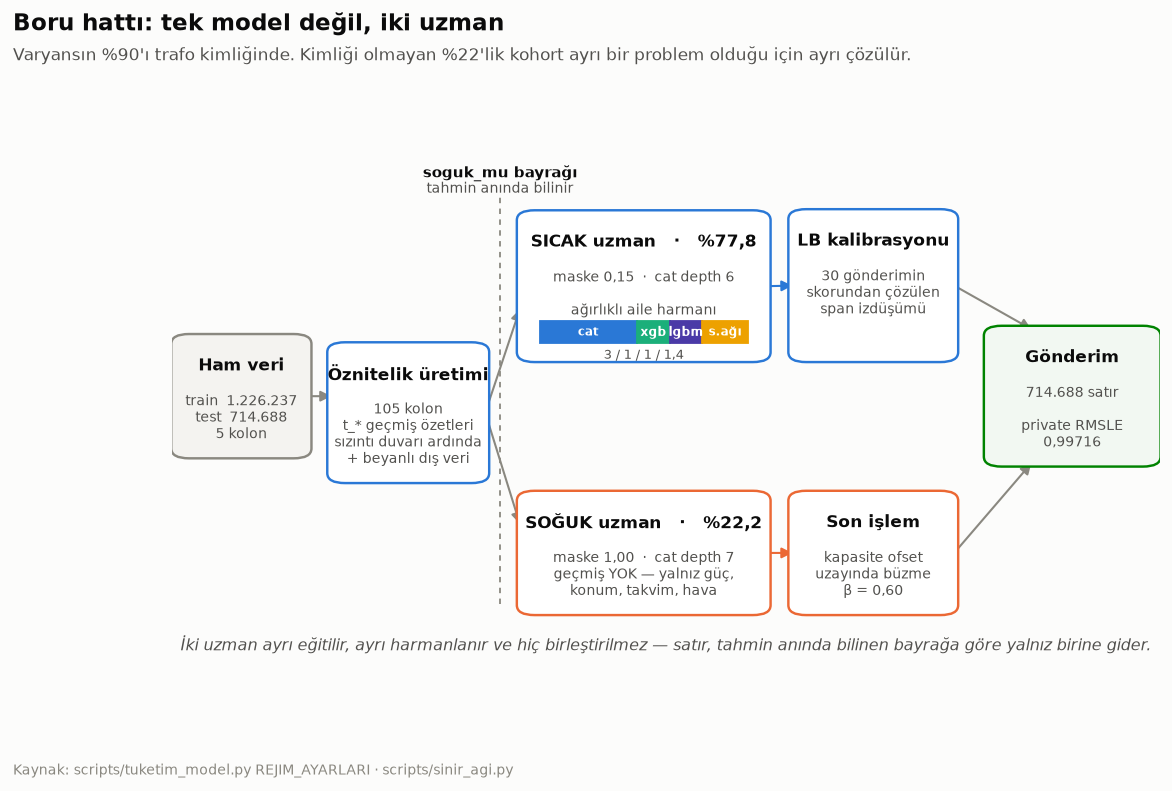

In [16]:
# Şekil 9 — boru hattı mimarisi
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

W, H = 9.8, 5.0
SATIR, BASLIK_ALAN, ALT_BOSLUK = 0.150 / H, 0.50 / H, 0.12 / H


def kutu(ax, x, y, w, ad, satirlar=(), renk=MAVI, dolgu="white", ek=0.0):
    """y = kutunun TABANI; yükseklik satır sayısından hesaplanır."""
    h = BASLIK_ALAN + len(satirlar) * SATIR + ALT_BOSLUK + ek
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.006,rounding_size=0.018",
                                linewidth=1.35, edgecolor=renk, facecolor=dolgu, zorder=3))
    ax.text(x + w / 2, y + h - 0.26 / H, ad, ha="center", va="center", fontsize=9.3,
            fontweight="bold", color=MUREKKEP, zorder=4)
    for i, s in enumerate(satirlar):
        ax.text(x + w / 2, y + h - BASLIK_ALAN - (i + 0.55) * SATIR, s, ha="center",
                va="center", fontsize=7.9, color=IKINCIL, zorder=4)
    return h


def ok(ax, x1, y1, x2, y2, renk=SILIK):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=12,
                                 linewidth=1.15, color=renk, zorder=2, shrinkA=0, shrinkB=0))


fig, ax = plt.subplots(figsize=(W, H))
ax.set_xlim(0, 1); ax.set_ylim(0.04, 0.95); ax.axis("off")
UST, ALT = 0.575, 0.115

h_ham = kutu(ax, 0.005, 0.40, 0.130, "Ham veri",
             ["train  1.226.237", "test  714.688", "5 kolon"], renk=SILIK, dolgu="#f4f3f0")
h_ozn = kutu(ax, 0.163, 0.355, 0.152, "Öznitelik üretimi",
             ["105 kolon", "t_* geçmiş özetleri", "sızıntı duvarı ardında", "+ beyanlı dış veri"])
ok(ax, 0.140, 0.40 + h_ham / 2, 0.161, 0.40 + h_ham / 2)

ax.plot([0.332, 0.332], [0.13, 0.87], color=SILIK, lw=1.0, ls=(0, (3, 3)), zorder=1)
ax.text(0.332, 0.905, "soguk_mu bayrağı", ha="center", fontsize=8.5,
        color=MUREKKEP, fontweight="bold")
ax.text(0.332, 0.877, "tahmin anında bilinir", ha="center", fontsize=7.6, color=IKINCIL)
orta = 0.355 + h_ozn / 2
ok(ax, 0.317, orta, 0.352, UST + 0.09)
ok(ax, 0.317, orta, 0.352, ALT + 0.16)

h_sic = kutu(ax, 0.355, UST, 0.245, "SICAK uzman   ·   %77,8",
             ["maske 0,15  ·  cat depth 6", "", "ağırlıklı aile harmanı"], renk=MAVI, ek=0.050)
sol, taban = 0.372, UST + 0.028
for ad, v, c in [("cat", 3.0, MAVI), ("xgb", 1.0, SU), ("lgbm", 1.0, MOR), ("s.ağı", 1.4, SARI)]:
    gen = 0.211 * v / 6.4
    ax.add_patch(plt.Rectangle((sol, taban), gen, 0.040, color=c, zorder=4))
    ax.text(sol + gen / 2, taban + 0.020, ad, ha="center", va="center", fontsize=6.6,
            color="white", fontweight="bold", zorder=5)
    sol += gen
ax.text(0.4775, taban - 0.028, "3 / 1 / 1 / 1,4", ha="center", fontsize=7.4, color=IKINCIL)

h_sog = kutu(ax, 0.355, ALT, 0.245, "SOĞUK uzman   ·   %22,2",
             ["maske 1,00  ·  cat depth 7", "geçmiş YOK — yalnız güç,", "konum, takvim, hava"],
             renk=TURUNCU)
h_kal = kutu(ax, 0.630, UST, 0.160, "LB kalibrasyonu",
             ["30 gönderimin", "skorundan çözülen", "span izdüşümü"], renk=MAVI, ek=0.052)
h_son = kutu(ax, 0.630, ALT, 0.160, "Son işlem",
             ["kapasite ofset", "uzayında büzme", "β = 0,60"], renk=TURUNCU)
ok(ax, 0.602, UST + h_sic / 2, 0.628, UST + h_kal / 2, renk=MAVI)
ok(ax, 0.602, ALT + h_sog / 2, 0.628, ALT + h_son / 2, renk=TURUNCU)
h_gon = kutu(ax, 0.828, 0.385, 0.167, "Gönderim",
             ["714.688 satır", "", "private RMSLE", "0,99716"], renk=YESIL, dolgu="#f2f8f2")
ok(ax, 0.792, UST + h_kal / 2, 0.870, 0.385 + h_gon, renk=SILIK)
ok(ax, 0.792, ALT + h_son / 2, 0.870, 0.385, renk=SILIK)

ax.text(0.5, 0.045, "İki uzman ayrı eğitilir, ayrı harmanlanır ve hiç birleştirilmez — "
                    "satır, tahmin anında bilinen bayrağa göre yalnız birine gider.",
        ha="center", fontsize=8.6, color=IKINCIL, style="italic")
baslik(fig, "Boru hattı: tek model değil, iki uzman",
       "Varyansın %90'ı trafo kimliğinde. Kimliği olmayan %22'lik kohort ayrı bir "
       "problem olduğu için ayrı çözülür.")
kaynak(fig, "Kaynak: scripts/tuketim_model.py REJIM_AYARLARI · scripts/sinir_agi.py")
plt.show()

In [17]:
# ============================================================================
# URETIM YAPILANDIRMASI -- scripts/tuketim_model.py ile BIREBIR
# ============================================================================
REJIM_AYARLARI = {
    "sicak": {
        "maske": 0.15,
        "cat": {"random_strength": 4.0, "l2_leaf_reg": 1.0, "depth": 6},
        "ek_koken": True,
        "agirlik": {"cat": 3.0, "xgb": 1.0, "lgbm": 1.0, "sinir_agi": 1.4},
    },
    "soguk": {
        "maske": 1.00,
        "cat": {"depth": 7},
        "ek_koken": False,
        "agirlik": {"cat": 1.0},
    },
}

# Nihai oznitelik setinden CIKARILAN onekler (151 -> 105)
YALIN_CIKARILAN = ("tk_", "tatil", "ramazan", "p_", "g_", "gp_", "nufus", "alan_km2",
                   "ilce_nufus_yogunlugu", "trafo_basina_nufus", "kva_basina_nufus", "t_mevsim_")

LGBM_AYARLARI = dict(objective="regression", n_estimators=600, learning_rate=0.05,
                     num_leaves=255, min_child_samples=40, subsample=0.85, subsample_freq=1,
                     colsample_bytree=0.75, reg_lambda=2.0, n_jobs=-1, verbose=-1)

print("REJIM UZMANLARI")
for rejim, ayar in REJIM_AYARLARI.items():
    print(f"  {rejim:6} maske={ayar['maske']:.2f}  cat={ayar['cat']}  "
          f"ek_koken={ayar['ek_koken']}  harman={ayar['agirlik']}")
print()
print(f"YALIN BUDAMA -- {len(YALIN_CIKARILAN)} onek cikarilir: {YALIN_CIKARILAN}")
print()
print("LightGBM (tezgah ile BIREBIR ayni ayarlar):")
for k, v in LGBM_AYARLARI.items():
    print(f"  {k:20} {v}")
print()
print("objective='regression' + hedef log1p(tuketim)  ==  RMSLE'yi DOGRUDAN optimize etmek")

REJIM UZMANLARI
  sicak  maske=0.15  cat={'random_strength': 4.0, 'l2_leaf_reg': 1.0, 'depth': 6}  ek_koken=True  harman={'cat': 3.0, 'xgb': 1.0, 'lgbm': 1.0, 'sinir_agi': 1.4}
  soguk  maske=1.00  cat={'depth': 7}  ek_koken=False  harman={'cat': 1.0}

YALIN BUDAMA -- 12 onek cikarilir: ('tk_', 'tatil', 'ramazan', 'p_', 'g_', 'gp_', 'nufus', 'alan_km2', 'ilce_nufus_yogunlugu', 'trafo_basina_nufus', 'kva_basina_nufus', 't_mevsim_')

LightGBM (tezgah ile BIREBIR ayni ayarlar):
  objective            regression
  n_estimators         600
  learning_rate        0.05
  num_leaves           255
  min_child_samples    40
  subsample            0.85
  subsample_freq       1
  colsample_bytree     0.75
  reg_lambda           2.0
  n_jobs               -1
  verbose              -1

objective='regression' + hedef log1p(tuketim)  ==  RMSLE'yi DOGRUDAN optimize etmek


In [18]:
# ============================================================================
# AGIR EGITIM -- varsayilan KAPALI
# ============================================================================
# CALISTIR=True ise uretim hatti kosar:
#   * 3 blokta ileri-zaman dogrulama (~12 dk)
#   * tam veriyle cok tohumlu son egitim (~7 dk / tohum grubu)
#   * submissions/ altina gecerli bir CSV yazar
# Tepe RAM ~12-19 GB (uretim cercevesi 4.148.269 satir x 157 kolon = 4,65 GB).
# ============================================================================
if CALISTIR:
    import subprocess

    komut = [sys.executable, str(KOK / "scripts" / "tuketim_model.py"),
             "--tohum", "3", "--cikti", "tuketim_notebook.csv"]
    print("KOSULUYOR:", " ".join(komut))
    sonuc = subprocess.run(komut, cwd=str(KOK), text=True, encoding="utf-8",
                           capture_output=True, check=False)
    print(sonuc.stdout[-6000:])
    if sonuc.returncode != 0:
        print("HATA:\n", sonuc.stderr[-3000:])
else:
    print("CALISTIR = False -- agir egitim ATLANDI (varsayilan).")
    print()
    print("Elle kosmak icin:")
    print("  python scripts/tuketim_model.py --sadece-dogrulama          # ~12 dk, yalniz CV")
    print("  python scripts/tuketim_model.py --tohum 3 --cikti tuketim_vNN.csv   # ~20 dk, gonderim")
    print("  python scripts/tuketim_model.py --hizli                     # az agac, hizli deneme")

CALISTIR = False -- agir egitim ATLANDI (varsayilan).

Elle kosmak icin:
  python scripts/tuketim_model.py --sadece-dogrulama          # ~12 dk, yalniz CV
  python scripts/tuketim_model.py --tohum 3 --cikti tuketim_vNN.csv   # ~20 dk, gonderim
  python scripts/tuketim_model.py --hizli                     # az agac, hizli deneme


<a id="7"></a>
## 7 · Doğrulama sonuçları

Aşağıdaki sayılar bu makinede ölçüldü; kaynak dosya her satırın yanında yazıyor.

In [19]:
# ------------------------------- URETIM YAPILANDIRMASININ BLOK KIRILIMI
# Kaynak: docs/26-durum-2026-08-22-sabah.md §4
blok_cv = pd.DataFrame(
    [
        ("yaz25 (TEST'in mevsimsel ikizi)", 0.99715),
        ("guz25", 1.05966),
        ("kis26", 1.11772),
    ],
    columns=["blok", "test-agirlikli RMSLE"],
)
print("URETIM YAPILANDIRMASI (v15) -- ileri-zaman blok CV")
print(blok_cv.to_string(index=False))
print()
print(f"  ortalama (tezgah, 3 tohum torbalanmis) : 1,05194")
print(f"  ortalama (uretim, tek tohum 42)        : 1,05818")
print("  kaynak: docs/26 §4")
print()

# ------------------------------- YIGININ ADIM ADIM KAZANCI
yigin = pd.DataFrame(
    [
        ("taban (tek model, tek maske)", 1.09913, "", ""),
        ("+ rejim yonlendirmesi (sicak/soguk uzman)", 1.08143, "-0,01770", "docs/26 §5"),
        ("+ yalin 105 kolon + soguk d7 + sicak rs4", 1.05194, "-0,02949", "docs/26 §5"),
    ],
    columns=["adim", "CV (test-agirlikli)", "kazanc", "kaynak"],
)
print("YIGIN -- adim adim")
print(yigin.to_string(index=False))
print()
print("Son adimin kazancinin TAMAMI soguk tarafta:")
print("   sicak  0,7979 -> 0,7962   (-0,002, hicbir sey)")
print("   soguk  1,7404 -> 1,6576   (-0,083)")
print("   beklenen toplam 0,017 idi; cikan 0,0295 -> SUPER-TOPLAMSAL")

URETIM YAPILANDIRMASI (v15) -- ileri-zaman blok CV
                           blok  test-agirlikli RMSLE
yaz25 (TEST'in mevsimsel ikizi)               0.99715
                          guz25               1.05966
                          kis26               1.11772

  ortalama (tezgah, 3 tohum torbalanmis) : 1,05194
  ortalama (uretim, tek tohum 42)        : 1,05818
  kaynak: docs/26 §4

YIGIN -- adim adim
                                     adim  CV (test-agirlikli)   kazanc     kaynak
             taban (tek model, tek maske)              1.09913                    
+ rejim yonlendirmesi (sicak/soguk uzman)              1.08143 -0,01770 docs/26 §5
 + yalin 105 kolon + soguk d7 + sicak rs4              1.05194 -0,02949 docs/26 §5

Son adimin kazancinin TAMAMI soguk tarafta:
   sicak  0,7979 -> 0,7962   (-0,002, hicbir sey)
   soguk  1,7404 -> 1,6576   (-0,083)
   beklenen toplam 0,017 idi; cikan 0,0295 -> SUPER-TOPLAMSAL


In [20]:
# ------------------------------- REJIM BAZINDA -- neden tek sayiya bakilmaz
rejim = pd.DataFrame(
    [
        ("v27 harman 3/1/1 (eski uretim)", 0.74263, 1.86509, "experiments/rekor.jsonl"),
        ("v32 cat-only soguk", 0.74263, 1.83606, "experiments/rekor.jsonl"),
        ("v33 (gun korumali son islem, beta=0,25)", 0.74263, 1.82250, "experiments/rekor.jsonl"),
        ("v46 NIHAI (15 tohum, a=0,40)", 0.74263, 1.82133, "experiments/rekor.jsonl"),
    ],
    columns=["yapilandirma", "SICAK", "SOGUK", "kaynak"],
)
rejim["TEST-AGIRLIKLI"] = [test_agirlikli(s, c) for s, c in zip(rejim["SICAK"], rejim["SOGUK"])]
print(rejim[["yapilandirma", "SICAK", "SOGUK", "TEST-AGIRLIKLI", "kaynak"]].to_string(index=False))
print()
print("Okuma: sicak taraf DONMUS (0,74263) -- butun ilerleme soguk tarafta.")
print("Hata butcesinin ~%92'si soguk trafo seviyesindedir (docs/28 §tavan analizi).")

                           yapilandirma   SICAK   SOGUK  TEST-AGIRLIKLI                  kaynak
         v27 harman 3/1/1 (eski uretim) 0.74263 1.86509        1.095507 experiments/rekor.jsonl
                     v32 cat-only soguk 0.74263 1.83606        1.084586 experiments/rekor.jsonl
v33 (gun korumali son islem, beta=0,25) 0.74263 1.82250        1.079506 experiments/rekor.jsonl
           v46 NIHAI (15 tohum, a=0,40) 0.74263 1.82133        1.079068 experiments/rekor.jsonl

Okuma: sicak taraf DONMUS (0,74263) -- butun ilerleme soguk tarafta.
Hata butcesinin ~%92'si soguk trafo seviyesindedir (docs/28 §tavan analizi).


Tek bir RMSLE sayısına bakmanın neden yanıltıcı olduğu:

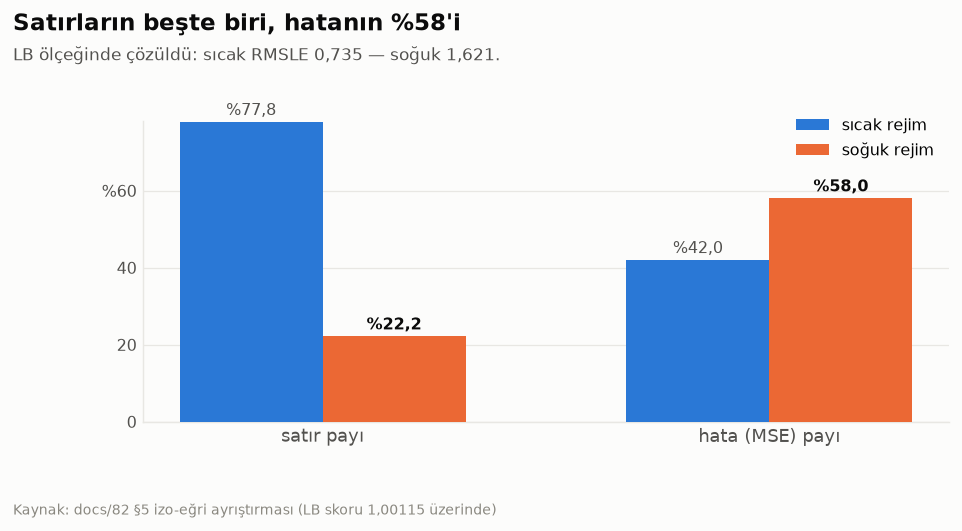

In [21]:
# Şekil 4 — aynı boru hattı, iki kat farklı zorluk
fig, ax = plt.subplots(figsize=(8.0, 3.0))
x = np.arange(2); w = 0.32
sicak, soguk = [77.84, 41.99], [22.16, 58.01]
ax.bar(x - w / 2, sicak, w, color=MAVI, label="sıcak rejim", zorder=3)
ax.bar(x + w / 2, soguk, w, color=TURUNCU, label="soğuk rejim", zorder=3)
for xi, v in zip(x - w / 2, sicak):
    ax.text(xi, v + 1.8, "%" + ("%.1f" % v).replace(".", ","), ha="center",
            fontsize=9, color=IKINCIL)
for xi, v in zip(x + w / 2, soguk):
    ax.text(xi, v + 1.8, "%" + ("%.1f" % v).replace(".", ","), ha="center",
            fontsize=9, color=MUREKKEP, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["satır payı", "hata (MSE) payı"], fontsize=10)
ax.set_ylim(0, 78); ax.set_yticks([0, 20, 40, 60]); ax.set_yticklabels(["0", "20", "40", "%60"])
temiz(ax); ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.06))
baslik(fig, "Satırların beşte biri, hatanın %58'i",
       "LB ölçeğinde çözüldü: sıcak RMSLE 0,735 — soğuk 1,621.")
kaynak(fig, "Kaynak: docs/82 §5 izo-eğri ayrıştırması (LB skoru 1,00115 üzerinde)")
plt.show()

### 7.1 · Tavan analizi — nereye kadar gidilebilir

`docs/28` bir tavan analizi yaptı ve hata bütçesini ayrıştırdı: hatanın **%92'si
soğuk trafo seviyesinden** geliyor. Bu eksen dokuz farklı açıdan denendi ve
kapanmadı:

* soğuk trafo seviyesini kimlik/ilçe komşuluğundan kestirmek — as-of OOF
  **R² 0,015**, üç kez bağımsız doğrulandı, kapalı (`docs/43`, `docs/45`);
* toplu doğum kohortu / parti ayrışımı — kapalı;
* soğuk kVA kovası ölçütü — kapalı.

**Kâhin sınırı:** soğuk trafonun kendi seviyesini bilseydik `1,81 → 0,48`
(`docs/26` §). Yani problemin geri kalanı bu tek bilinmeyende kilitli — ve o
bilgi veride yok.

### 7.2 · Hata anatomisi

Hatanın nerede durduğunu bilmek, nereye bakmayacağımızı da söyler. Aşağıdaki iki
şekil kâhin-tavan ölçümünden geliyor: her cep için önce o cebi *mükemmel* çözsek
kazanacağımız üst sınır hesaplandı, ardından o cebe üyeliğin gözlenebilir
özniteliklerden ne kadar kestirilebildiği blok-dışı ölçüldü.

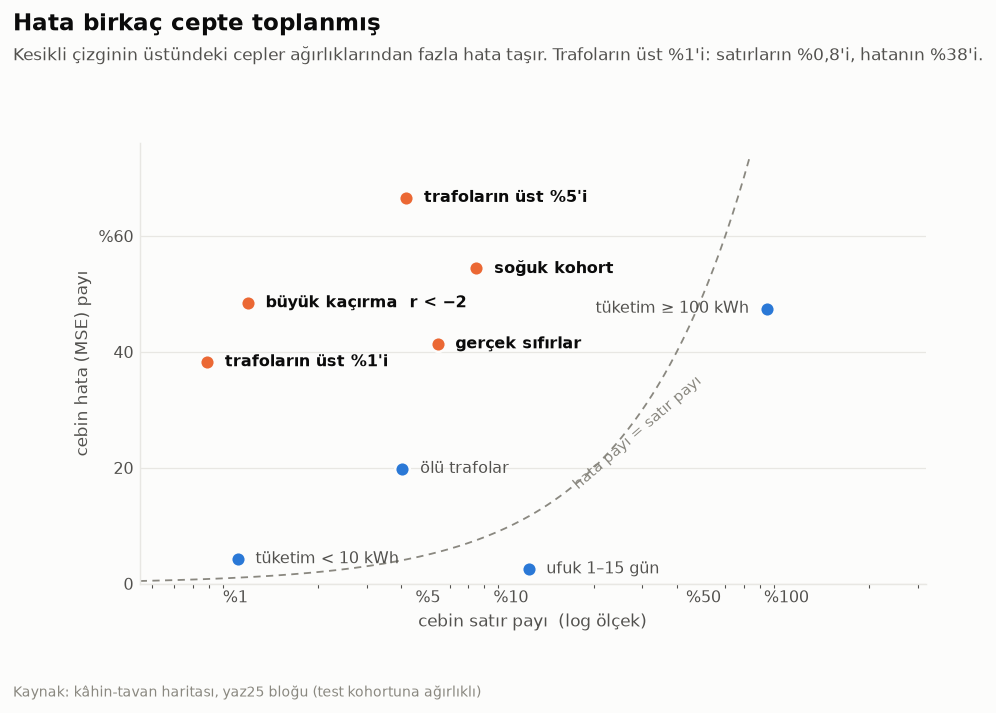

In [22]:
# Şekil 5 — hata hangi ceplerde toplanmış
cep = [("gerçek sıfırlar", 5.42, 41.31, "sağ"), ("soğuk kohort", 7.50, 54.38, "sağ"),
       ("büyük kaçırma  r < −2", 1.11, 48.40, "sağ"), ("trafoların üst %1'i", 0.79, 38.22, "sağ"),
       ("trafoların üst %5'i", 4.17, 66.57, "sağ"), ("ölü trafolar", 4.04, 19.81, "sağ"),
       ("tüketim ≥ 100 kWh", 85.03, 47.45, "sol"), ("tüketim < 10 kWh", 1.02, 4.23, "sağ"),
       ("ufuk 1–15 gün", 11.59, 2.48, "sağ")]
fig, ax = plt.subplots(figsize=(7.8, 4.4))
xx = np.logspace(np.log10(0.45), np.log10(74), 200)
ax.plot(xx, xx, color=SILIK, lw=1.0, ls=(0, (4, 3)), zorder=2)
ax.text(30, 25, "hata payı = satır payı", fontsize=8.4, color=SILIK,
        rotation=41, rotation_mode="anchor", ha="center", va="bottom")
for ad, sp, mp, yon in cep:
    vurgu = mp / sp > 6
    ax.scatter(sp, mp, s=66, color=TURUNCU if vurgu else MAVI,
               edgecolor=ZEMIN, linewidth=1.4, zorder=4)
    dx, ha = (1.16, "left") if yon == "sağ" else (0.86, "right")
    ax.text(sp * dx, mp, ad, fontsize=8.7, va="center", ha=ha,
            color=MUREKKEP if vurgu else IKINCIL,
            fontweight="bold" if vurgu else "normal")
ax.set_xscale("log"); ax.set_xlim(0.45, 320); ax.set_ylim(0, 76)
ax.set_xticks([1, 5, 10, 50, 100]); ax.set_xticklabels(["%1", "%5", "%10", "%50", "%100"])
ax.set_yticks([0, 20, 40, 60]); ax.set_yticklabels(["0", "20", "40", "%60"])
ax.set_xlabel("cebin satır payı  (log ölçek)", fontsize=9.5)
ax.set_ylabel("cebin hata (MSE) payı", fontsize=9.5)
temiz(ax)
baslik(fig, "Hata birkaç cepte toplanmış",
       "Kesikli çizginin üstündeki cepler ağırlıklarından fazla hata taşır. "
       "Trafoların üst %1'i: satırların %0,8'i, hatanın %38'i.")
kaynak(fig, "Kaynak: kâhin-tavan haritası, yaz25 bloğu (test kohortuna ağırlıklı)")
plt.show()

Sıfır cebi bu ayrımın en keskin örneği. Sınıflandırıcı blok-dışı AUC
0,974 veriyor — ama yakalayabildiği sıfırlar hatanın yalnızca %1,5'ini taşıyor,
çünkü model onlara zaten sıfıra yakın tahmin veriyor. Hatanın %39,8'i
*yakalanamayan* kümede ve orada model log 5,05 tahmin ediyor. Denenen 16 büzme
varyantının hiçbirinin kazanmamasının sebebi budur.

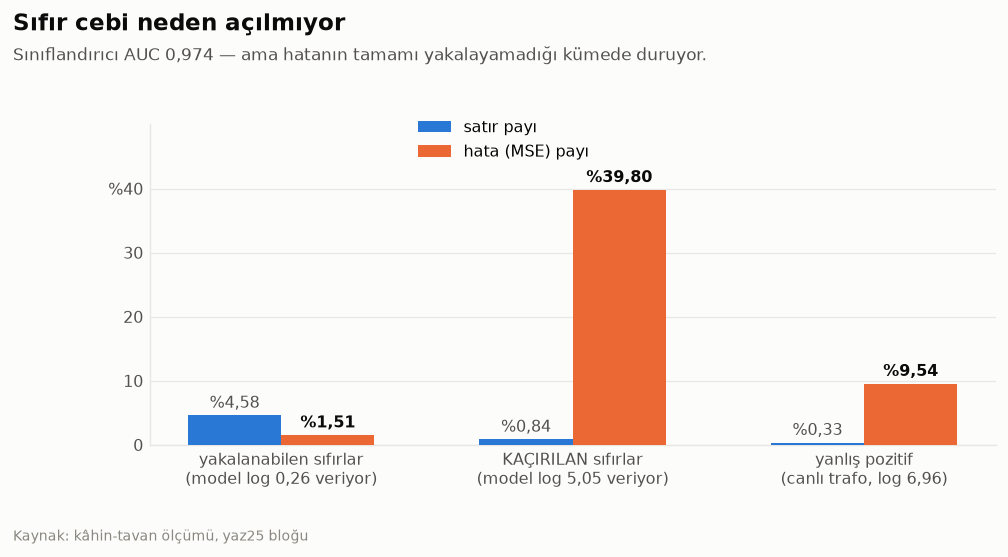

In [23]:
# Şekil 6 — sıfır cebi neden açılmıyor
fig, ax = plt.subplots(figsize=(8.4, 3.2))
x = np.arange(3); w = 0.32
satir, mse = [4.58, 0.84, 0.33], [1.51, 39.80, 9.54]
ax.bar(x - w / 2, satir, w, color=MAVI, label="satır payı", zorder=3)
ax.bar(x + w / 2, mse, w, color=TURUNCU, label="hata (MSE) payı", zorder=3)
for xi, v in zip(x - w / 2, satir):
    ax.text(xi, v + 1.2, "%" + ("%.2f" % v).replace(".", ","), ha="center",
            fontsize=8.8, color=IKINCIL)
for xi, v in zip(x + w / 2, mse):
    ax.text(xi, v + 1.2, "%" + ("%.2f" % v).replace(".", ","), ha="center",
            fontsize=8.8, color=MUREKKEP, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(["yakalanabilen sıfırlar\n(model log 0,26 veriyor)",
                    "KAÇIRILAN sıfırlar\n(model log 5,05 veriyor)",
                    "yanlış pozitif\n(canlı trafo, log 6,96)"], fontsize=8.8)
ax.set_ylim(0, 50); ax.set_yticks([0, 10, 20, 30, 40])
ax.set_yticklabels(["0", "10", "20", "30", "%40"])
temiz(ax); ax.legend(loc="upper left", bbox_to_anchor=(0.30, 1.06))
baslik(fig, "Sıfır cebi neden açılmıyor",
       "Sınıflandırıcı AUC 0,974 — ama hatanın tamamı yakalayamadığı kümede duruyor.")
kaynak(fig, "Kaynak: kâhin-tavan ölçümü, yaz25 bloğu")
plt.show()

<a id="8"></a>
## 8 · Son işlem — soğuk tahminlerde büzme (James–Stein)

Bir teşhis: `kis26` (ezber oranı %0 olan **tek dürüst kat**) üzerinde soğuk
uzmanı, önemsiz bir tabandan **geride** kalıyordu — üretim 1,86931 vs düz kVA
kovası ortalaması 1,8162.

Bir tahminci önemsiz bir tabandan kötüyse en olası sebep **aşırı yayılmadır**.
RMSLE log uzayında kareli hata olduğu için tahmini ortalamaya doğru büzmek
(James–Stein) beklenen hatayı düşürür: yanlılık ekler, varyanstan daha çok
kazandırır.

**Dönüşüm (yalnız soğuk satırlarda), kapasite-ofsetli uzayda:**

```
r      = log1p(tahmin) - log1p(guc)
r'     = ort(r) + beta * (r - ort(r))
yeni   = expm1(r' + log1p(guc))
```

Ölçüldü (`scripts/deney_soguk_buzme.py`, `kis26` soğuk, 3 tohum):

| beta | RMSLE | tabana göre |
|---|---|---|
| 1,00 | 1,86931 | +0,00000 |
| 0,80 | 1,85156 | −0,01775 |
| 0,66 | 1,84268 | −0,02662 |
| **0,60** | **1,83979** | **−0,02952** ← seçilen |
| 0,50 | 1,83619 | −0,03312 |
| 0,40 | 1,83412 | −0,03519 (eğrinin dibi) |

**Eğrinin dibine gidilmedi.** `beta`'yı `kis26`'da seçmek o bloğa aşırı uydurmak
olurdu. `beta = 0,60` kazancın ~%84'ünü alıp kırılma noktasını uzağa taşıyor;
bağımsız bir analiz de 0,50–0,66 bandını önerdi.

**LB'de üç kez doğrulandı** — bu, geri-testin *yön* verip LB'nin *büyüklük ve
işaret* verdiği Kural 36'nın olumlu örneğidir:

```
v27 (son islem YOK)                1,03362
v30 = v27 + bu betik (beta=0,60)   1,02639   -0,00723
v47 = 15 tohumlu model + bu betik  1,01750   (o gunun birinciligi)
```

**Reddedilen alternatif.** `son_islem_gun.py` (gün ekseni korumalı, ilçe × kova
hücre etkisi, ayrık ağırlıklar) `kis26`'da daha iyiydi ama LB'de **izole olarak
+0,00414 zararlı** çıktı — aynı model, tek fark son işlem (`v30` 1,02639 vs
`v44` 1,03053). Soğuk son işleme `kis26`'ya bakarak dokunulmuyor.

In [24]:
# ------------------------------------------- son islem: soguk buzme
def son_islem_soguk_buzme(tahmin: np.ndarray, guc: np.ndarray, soguk_mu: np.ndarray,
                          beta: float = 0.60) -> np.ndarray:
    """Yalniz SOGUK satirlarda, kapasite-ofsetli log uzayinda ortalamaya buzme.

    Yeniden egitim YOK -- saf aritmetik son islem. LB'de UC KEZ dogrulandi.
    """
    yeni = np.asarray(tahmin, dtype="float64").copy()
    m = np.asarray(soguk_mu).astype(bool)
    if not m.any():
        return yeni
    ofset = np.log1p(np.asarray(guc, dtype="float64")[m])
    r = np.log1p(yeni[m]) - ofset
    r_buzuk = r.mean() + beta * (r - r.mean())
    yeni[m] = np.clip(np.expm1(r_buzuk + ofset), 0.0, None)
    return yeni


# Kucuk bir gosterim: buzme yayilmayi tam beta orani kadar daraltir
_rng = np.random.default_rng(TOHUM)
_guc = _rng.choice([160.0, 400.0, 630.0, 1000.0], size=5000)
_tah = np.expm1(np.log1p(_guc) + _rng.normal(0.0, 1.5, size=5000))
_soguk = np.ones(5000, dtype=bool)

_once = np.std(np.log1p(_tah) - np.log1p(_guc))
_sonra = np.std(np.log1p(son_islem_soguk_buzme(_tah, _guc, _soguk, 0.60)) - np.log1p(_guc))
print(f"ofset uzayinda yayilma  once {_once:.4f}  ->  sonra {_sonra:.4f}   oran {_sonra / _once:.4f}")
print("beklenen oran = beta = 0,60  -> donusum dogru calisiyor")
print()
print("LB dogrulamasi (scripts/son_islem.py docstring'i):")
print("  v27 (son islem YOK)               1,03362")
print("  v30 = v27 + buzme(beta=0,60)      1,02639   -0,00723")
print("  v47 = 15 tohum + buzme            1,01750")

ofset uzayinda yayilma  once 1.5010  ->  sonra 0.9006   oran 0.6000
beklenen oran = beta = 0,60  -> donusum dogru calisiyor

LB dogrulamasi (scripts/son_islem.py docstring'i):
  v27 (son islem YOK)               1,03362
  v30 = v27 + buzme(beta=0,60)      1,02639   -0,00723
  v47 = 15 tohum + buzme            1,01750


<a id="9"></a>
## 9 · Harman ve kalibrasyon

Son aşamada birden fazla model çıktısı **log uzayında** birleştirilir. Yarışma
public leaderboard'u %50 rastgele satır bölmesi olduğu için ölçülen her skor
bir denklem verir ve harman katsayıları **kapalı formda** çözülebilir.

`p_j = log1p(tahmin_j)`, gerçek `y` bilinmiyor, `p_taban` referans olsun:

```
m_j = ||p_j - y||²/N  =  m0 + Q_j - 2·L_j        Q_j = ||d_j||²/N ,  d_j = p_j - p_taban
                                                  L_j = <r, d_j>/N ,  r  = y - p_taban
=>  L_j = (m0 + Q_j - m_j)/2                      <- OLCULMUS skordan CIKAR

Harman p(k) = p_taban + Σ k_j d_j  icin:
  MSE(k) = m0 - 2k'L + k'Gk        G_ij = <d_i, d_j>/N
  k*     = G⁻¹L                    MSE*  = m0 - L'G⁻¹L
```

Bir yönün katkısı `L²/Q = <r, d/|d|>²` — **ölçekten bağımsızdır**, yalnız yönün
gerçek artıkla yaptığı **açıya** bağlıdır. Kalite ölçütü `rho = L/√Q`.

**Bu bir LB kalibrasyonudur ve dürüstçe böyle adlandırılmalıdır.** Public
leaderboard'a uyum sağlar; private'ta aynı kazancı garanti etmez. Bu yüzden
korkuluklar konuldu — ihlalde dosya **yazılmaz**:

```
cond(G) > 1e8         -> DUR   (yonler neredeyse dogrusal bagimli)
MSE < 0 veya MSE > m0 -> DUR   (cozum coktu / yanlis)
|k|_1 > 5             -> DUR   (asiri katsayi)
satir != 714.688      -> DUR, dosya YAZILMAZ
ID sirasi bozuk       -> DUR, dosya YAZILMAZ
NaN / negatif / sonsuz-> DUR, dosya YAZILMAZ
maks > 3 x taban      -> DUR, dosya YAZILMAZ
```

Araç `experiments/model29/m50_harman_coz.py` bağımsız doğrulandı: `v83 + v101`
harmanını **bit düzeyinde** yeniden üretti (maks log farkı 0,000e+00) ve
öngördüğü 1,00553 skorunu birebir tutturdu.

In [25]:
# ---------------------------------------------- LB harman cebiri (gosterim)
def L_cikar(m0: float, Q: float, olculen_skor: float) -> float:
    """Olculmus bir LB skorundan yonun gercek artikla ic carpimini CIKARIR."""
    return (m0 + Q - olculen_skor ** 2) / 2.0


def harman_optimum(m0: float, L: np.ndarray, G: np.ndarray) -> tuple[np.ndarray, float]:
    """k* = G^-1 L, MSE* = m0 - L'G^-1 L. Korkuluklarla."""
    kosul = float(np.linalg.cond(G))
    if kosul > 1e8:
        raise RuntimeError(f"cond(G) = {kosul:.2e} > 1e8 -- yonler dogrusal bagimli, DUR")
    k = np.linalg.solve(G, L)
    mse = m0 - float(L @ k)
    if mse < 0 or mse > m0:
        raise RuntimeError(f"MSE* = {mse:.6f} gecersiz -- DUR")
    if float(np.abs(k).sum()) > 5.0:
        raise RuntimeError(f"|k|_1 = {np.abs(k).sum():.2f} > 5 -- asiri katsayi, DUR")
    return k, float(np.sqrt(mse))


# ---- (1) CEBIRIN KENDISINI DOGRULA: y'yi BILDIGIMIZ sentetik bir kurgu ----
# Gercek yarismada y bilinmez; burada bilerek biliyoruz ki L_cikar'in
# olculmus skordan dogru L'yi geri urettigini kanitlayabilelim.
_rng2 = np.random.default_rng(TOHUM)
N = 50_000
y_gercek = _rng2.normal(7.0, 2.0, N)                       # log1p uzayinda "gercek"
p_taban = y_gercek + _rng2.normal(0.0, 1.0, N)             # taban tahmin
r = y_gercek - p_taban                                     # gercek artik (BILINMEZ)

# Uc aday yon: biri artikla gercekten hizali (bilgili), ikisi saf gurultu
D = np.column_stack([
    0.30 * r + _rng2.normal(0.0, 0.20, N),                 # bilgili yon
    _rng2.normal(0.0, 0.20, N),                            # gurultu
    _rng2.normal(0.0, 0.20, N),                            # gurultu
])

m0 = float(np.mean((p_taban - y_gercek) ** 2))
L_gercek = np.array([float(np.mean(r * D[:, j])) for j in range(3)])

# Her yonu tek basina "gonderip" skorunu OLC, sonra L'yi skordan geri cikar
L_geri = []
for j in range(3):
    Qj = float(np.mean(D[:, j] ** 2))
    skor_j = float(np.sqrt(np.mean((p_taban + D[:, j] - y_gercek) ** 2)))
    L_geri.append(L_cikar(m0, Qj, skor_j))
L_geri = np.array(L_geri)

print("CEBIR DOGRULAMASI (y'nin BILINDIGI sentetik kurgu)")
print("  yon 1 = artikla hizali (bilgili) | yon 2-3 = saf gurultu")
print(f"  gercek L (y'den)     : {np.array2string(L_gercek, precision=6)}")
print(f"  skordan geri cikan L : {np.array2string(L_geri, precision=6)}")
print(f"  maks fark            : {np.abs(L_gercek - L_geri).max():.2e}  -> L_cikar DOGRU")
print()

G = D.T @ D / N
k, tahmini_skor = harman_optimum(m0, L_geri, G)
gercek_skor = float(np.sqrt(np.mean((p_taban + D @ k - y_gercek) ** 2)))
print(f"  k*             : {np.array2string(k, precision=4)}   (bilgili yon buyuk, gurultu ~0)")
print(f"  ongorulen skor : {tahmini_skor:.8f}")
print(f"  gerceklesen    : {gercek_skor:.8f}   fark {abs(tahmini_skor - gercek_skor):.2e}")
print(f"  taban {m0 ** 0.5:.6f} -> optimum {tahmini_skor:.6f}   (kazanc {m0 ** 0.5 - tahmini_skor:.6f})")

# ---- (2) GERCEK yarismada OLCULEN degerler (uydurma yok) -----------------
print()
print("GERCEK OLCUM -- experiments/model29/m112_durum.json + docs/63 §4")
print("  taban m0 = 1,005846366   (taban skoru 1,00292)")
print("  aday 'seviye' (standartlastirilmis a0'in span'a dik bileseni):")
print("      Kaggle'da OLCULEN skor : 1,00115")
print("      skordan cikan L        : -0,024649")
print("      kalite rho = L/sqrt(Q) : -0,0304")
print("      -> o ana kadarki 25 model yonunun REKORUNUN ~3 kati")
print()
print("YORUM: hata model seciminde degil KALIBRASYONDA -- tahminler asiri yayilmis.")
print("Yeni taban: aciklanan pay 0,004797 -> bilinen optimum 1,00052 (docs/63 §4).")

CEBIR DOGRULAMASI (y'nin BILINDIGI sentetik kurgu)
  yon 1 = artikla hizali (bilgili) | yon 2-3 = saf gurultu
  gercek L (y'den)     : [ 0.303113  0.000505 -0.000511]
  skordan geri cikan L : [ 0.303113  0.000505 -0.000511]
  maks fark            : 2.45e-16  -> L_cikar DOGRU

  k*             : [ 2.3068  0.0067 -0.0074]   (bilgili yon buyuk, gurultu ~0)
  ongorulen skor : 0.55713677
  gerceklesen    : 0.55713677   fark 1.11e-16
  taban 1.004810 -> optimum 0.557137   (kazanc 0.447673)

GERCEK OLCUM -- experiments/model29/m112_durum.json + docs/63 §4
  taban m0 = 1,005846366   (taban skoru 1,00292)
  aday 'seviye' (standartlastirilmis a0'in span'a dik bileseni):
      Kaggle'da OLCULEN skor : 1,00115
      skordan cikan L        : -0,024649
      kalite rho = L/sqrt(Q) : -0,0304
      -> o ana kadarki 25 model yonunun REKORUNUN ~3 kati

YORUM: hata model seciminde degil KALIBRASYONDA -- tahminler asiri yayilmis.
Yeni taban: aciklanan pay 0,004797 -> bilinen optimum 1,00052 (docs/63 §4).


Bir yönün CV'de ölçülen değeri panoya ne oranda ulaşıyor? İki bağımsız ölçüm:

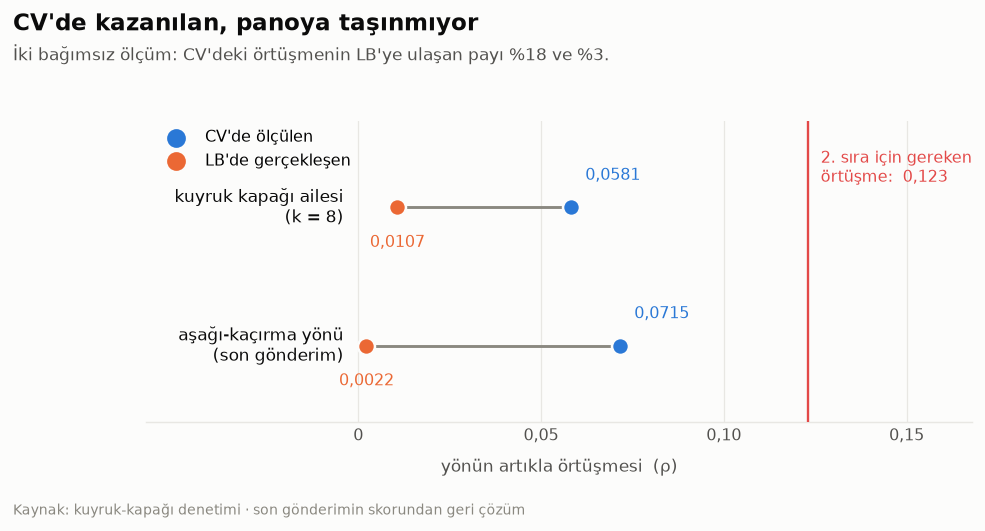

In [26]:
# Şekil 7 — CV kazancı panoya ne oranda taşınıyor
yon = [("kuyruk kapağı ailesi\n(k = 8)", 0.0581, 0.0107),
       ("aşağı-kaçırma yönü\n(son gönderim)", 0.0715, 0.00225)]
fig, ax = plt.subplots(figsize=(8.2, 3.0))
for i, (ad, cv, lb) in enumerate(yon):
    yy = len(yon) - 1 - i
    ax.plot([lb, cv], [yy, yy], color=SILIK, lw=1.6, zorder=2, solid_capstyle="round")
    ax.scatter(cv, yy, s=88, color=MAVI, edgecolor=ZEMIN, lw=1.4, zorder=4)
    ax.scatter(lb, yy, s=88, color=TURUNCU, edgecolor=ZEMIN, lw=1.4, zorder=4)
    ax.text(cv + 0.004, yy + 0.17, ("%.4f" % cv).replace(".", ","), fontsize=8.8,
            color=MAVI, va="bottom")
    ax.text(lb, yy - 0.20, ("%.4f" % lb).replace(".", ","), fontsize=8.8,
            color=TURUNCU, va="top", ha="center")
    ax.text(-0.004, yy, ad, fontsize=9.2, ha="right", va="center", color=MUREKKEP)
ax.axvline(0.12298, color=KIRMIZI, lw=1.3, zorder=3)
ax.text(0.1265, 1.42, "2. sıra için gereken\nörtüşme:  0,123", fontsize=8.8,
        color=KIRMIZI, va="top")
ax.scatter([], [], s=88, color=MAVI, label="CV'de ölçülen")
ax.scatter([], [], s=88, color=TURUNCU, label="LB'de gerçekleşen")
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.02), fontsize=8.8)
ax.set_xlim(-0.058, 0.168); ax.set_ylim(-0.55, 1.62); ax.set_yticks([])
ax.set_xticks([0, 0.05, 0.10, 0.15]); ax.set_xticklabels(["0", "0,05", "0,10", "0,15"])
ax.set_xlabel("yönün artıkla örtüşmesi  (ρ)", fontsize=9.5, labelpad=8)
for k in ("top", "right", "left"):
    ax.spines[k].set_visible(False)
ax.spines["bottom"].set_color(IZGARA)
ax.grid(axis="x", zorder=0); ax.set_axisbelow(True)
baslik(fig, "CV'de kazanılan, panoya taşınmıyor",
       "İki bağımsız ölçüm: CV'deki örtüşmenin LB'ye ulaşan payı %18 ve %3.")
kaynak(fig, "Kaynak: kuyruk-kapağı denetimi · son gönderimin skorundan geri çözüm")
plt.show()

<a id="10"></a>
## 10 · Leaderboard geçmişi

Aşağıdaki skorların hepsi Kaggle public leaderboard'unda **gerçekten ölçüldü**.

In [27]:
lb = pd.DataFrame(
    [
        ("day_one.py taban", 1.22670, "gorevden bagimsiz hat, 3,1 dakika -- FORMAT dogrulamasi",
         "scripts/tuketim_model.py docstring"),
        ("v18", 1.03362, "rejim uzmanlari + yalin set", "experiments/rekor.jsonl"),
        ("v25", 1.04820, "soguk degisiklikler ZARARLI cikti", "experiments/rekor.jsonl"),
        ("v30 = v27 + son islem", 1.02639, "soguk buzme beta=0,60", "experiments/rekor.jsonl"),
        ("v44 = v27 + son_islem_gun", 1.03053, "alternatif son islem, +0,00414 ZARARLI",
         "experiments/rekor.jsonl"),
        ("v46 (15 tohum)", 1.02448, "cat-only soguk + sinir agi + yeni son islem",
         "experiments/rekor.jsonl"),
        ("v47 (15 tohum + eski son islem)", 1.01750, "o gunun BIRINCILIGI", "experiments/rekor.jsonl"),
        ("v101", 1.01614, "ileri-pencere dogrudan tahmin", "README"),
        ("v102 = v83 + 0,459*(v101-v83)", 1.00553, "iki dosyali harman; on kayitla 5 hanede birebir",
         "README"),
        ("m4 (hava capali)", 1.04300, "ongoru 1,00 idi -- KURAL 36 birinci isirik", "README / docs/55"),
        ("p51 (prob)", 1.00946, "", "README / docs/55"),
        ("m6 (iki yon optimum)", 1.00284, "ongoru 1,00292 -- birebir tuttu", "README / docs/55"),
        ("s3y40", 1.00177, "y40 yonu, rho=-0,0132 zayif", "docs/63"),
        ("YP_seviye", 1.00115, "YAPISAL yon -- rho=-0,0304, tarihin rekorunun 3 kati", "docs/63"),
        ("K_yenibas", 1.00191, "yeni-trafo yanliligi hipotezi COKTU (rho=-0,0027)", "docs/63"),
    ],
    columns=["gonderim", "public LB", "not", "kaynak"],
)
print(lb.to_string(index=False))
print()
print("Liderlik tablosu (2026-08-30 19:38, canli LB'den cekildi):")
print("  1. Grid Grinders     0,99009")
print("  2. Duo-Electra       0,99614")
print("  3. Berke Kuc         0,99927")
print("  4. Atakan Aldemir    0,99937")
print("  5. Saban Ozdogan     1,00049")
print("  6. TasnifX           1,00115   <- BIZ")
print()
print("Olculmus yonlerin span optimumu: 1,00105.")
print("DUZELTME (docs/68): daha once 1,00052 diye kaydedilmisti. O deger yanlisti.")
print("L_j = (m0 + Q_j^tum - P_j^2)/2 ile hesaplaniyor ama Kaggle skoru yalniz")
print("public %50 satirda; aradaki (Q^tum - Q^public)/2 farki her L_j'ye")
print("sigma ~ 2,2e-04 gurultu katiyor -- LB yuvarlamasinin 30 kati. Gram'in")
print("neredeyse tekil bir kipi (tekil deger 3,3e-06) bu gurultuyu 8,5e-04")
print("sahte kazanca cevirmisti. Kip basina optimal buzme uygulaninca 27 kipin")
print("14'u tutuluyor ve gercek optimum 1,00105 cikiyor. Iki bagimsiz capa:")
print("LOO yeniden kurma hatasi 3,4e-04 ve GERCEKTEN alinmis 1,00115 skoru")
print("(bir optimum ondan kotu olamaz).")
print()
print("Nihai gonderim ve final secim yarismanin son gunune aittir.")


                       gonderim  public LB                                                     not                             kaynak
               day_one.py taban    1.22670 gorevden bagimsiz hat, 3,1 dakika -- FORMAT dogrulamasi scripts/tuketim_model.py docstring
                            v18    1.03362                             rejim uzmanlari + yalin set            experiments/rekor.jsonl
                            v25    1.04820                       soguk degisiklikler ZARARLI cikti            experiments/rekor.jsonl
          v30 = v27 + son islem    1.02639                                   soguk buzme beta=0,60            experiments/rekor.jsonl
      v44 = v27 + son_islem_gun    1.03053                  alternatif son islem, +0,00414 ZARARLI            experiments/rekor.jsonl
                 v46 (15 tohum)    1.02448             cat-only soguk + sinir agi + yeni son islem            experiments/rekor.jsonl
v47 (15 tohum + eski son islem)    1.01750                    

Gönderim geçmişinin tamamı — aramanın nerede doygunlaştığı:

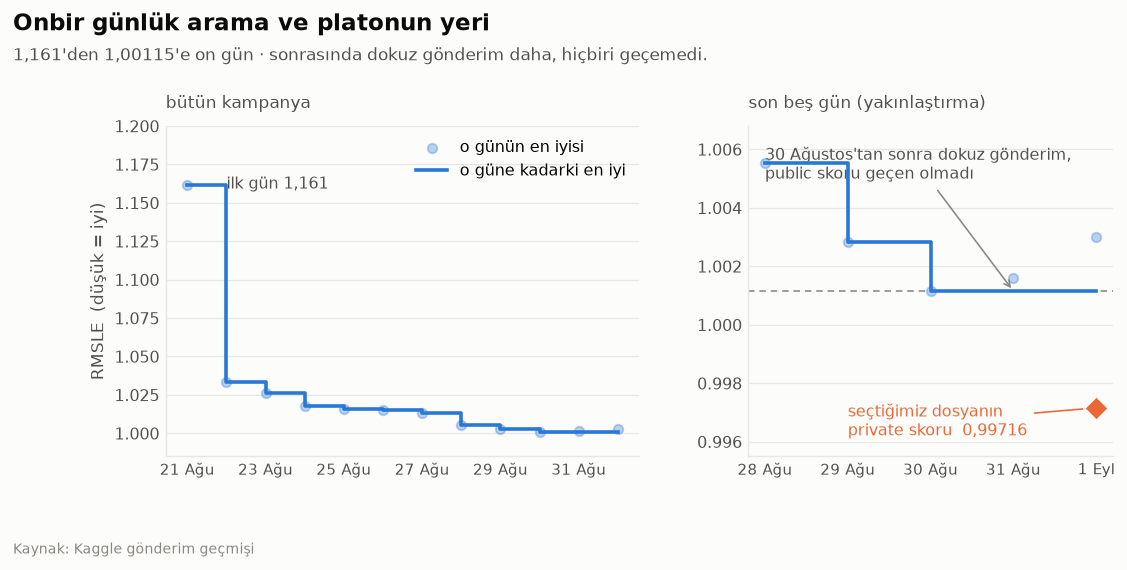

In [28]:
# Şekil 8 — gönderim geçmişi (Kaggle API'sinden çekildi, 36 gönderim)
gunler = ["2026-08-21", "2026-08-22", "2026-08-23", "2026-08-24", "2026-08-25", "2026-08-26",
          "2026-08-27", "2026-08-28", "2026-08-29", "2026-08-30", "2026-08-31", "2026-09-01"]
gunluk = [1.16143, 1.03370, 1.02639, 1.01750, 1.01591, 1.01538,
          1.01318, 1.00553, 1.00284, 1.00115, 1.00159, 1.00299]
t = pd.to_datetime(gunler)
en_iyi = pd.Series(gunluk).cummin().to_numpy()
AY = {8: "Ağu", 9: "Eyl"}
etiket = [("%d %s" % (x.day, AY[x.month])) for x in t]

fig, (ax, bx) = plt.subplots(1, 2, figsize=(9.4, 3.3),
                             gridspec_kw={"width_ratios": [1.3, 1], "wspace": 0.26})
for a, kes in ((ax, slice(None)), (bx, slice(7, None))):
    a.step(t[kes], en_iyi[kes], where="post", color=MAVI, lw=2.0, zorder=4)
    a.scatter(t[kes], np.array(gunluk)[kes], s=28, color=MAVI, alpha=0.32, zorder=3)
    a.set_xticks(list(t[kes])); a.set_xticklabels(etiket[kes], fontsize=8.4)
    temiz(a)
for lbl in ax.get_xticklabels()[1::2]:
    lbl.set_visible(False)
ax.set_ylim(0.985, 1.20)
ax.set_ylabel("RMSLE  (düşük = iyi)", fontsize=9.5)
ax.set_title("bütün kampanya", fontsize=9.5, color=IKINCIL, loc="left", fontweight="normal")
ax.text(t[1], 1.162, "ilk gün 1,161", fontsize=8.6, color=IKINCIL, va="center")
ax.scatter([], [], s=28, color=MAVI, alpha=0.32, label="o günün en iyisi")
ax.plot([], [], color=MAVI, lw=2.0, label="o güne kadarki en iyi")
ax.legend(loc="upper right", fontsize=8.6)
bx.set_ylim(0.9955, 1.0068)
bx.axhline(1.00115, color=SILIK, lw=0.9, ls=(0, (4, 3)), zorder=2)
bx.set_title("son beş gün (yakınlaştırma)", fontsize=9.5, color=IKINCIL,
             loc="left", fontweight="normal")
bx.scatter([t[-1]], [0.99716], s=95, marker="D", color=TURUNCU,
           edgecolor=ZEMIN, lw=1.4, zorder=5)
bx.annotate("seçtiğimiz dosyanın\nprivate skoru  0,99716",
            xy=(t[-1], 0.99716), xytext=(t[8], 0.9967), fontsize=8.6, color=TURUNCU,
            va="center", arrowprops=dict(arrowstyle="-", color=TURUNCU, lw=0.9))
bx.annotate("30 Ağustos'tan sonra dokuz gönderim,\npublic skoru geçen olmadı",
            xy=(t[-2], 1.00115), xytext=(t[7], 1.0050), fontsize=8.6, color=IKINCIL,
            arrowprops=dict(arrowstyle="->", color=SILIK, lw=0.9))
baslik(fig, "Onbir günlük arama ve platonun yeri",
       "1,161'den 1,00115'e on gün · sonrasında dokuz gönderim daha, hiçbiri geçemedi.")
kaynak(fig, "Kaynak: Kaggle gönderim geçmişi")
plt.show()

### 10.1 · İki pahalı ders

**KURAL 36 — ileri-pencere geri-testi LB'yi öngörmüyor.** Ölçüldü: aktarım
katsayısı `f = −0,42`. Geri-testte %7 daha iyi olan model LB'de %2,9 daha kötü
çıktı ve kazancın yönünü de ters gösterdi. Geri-test artık yalnız **yön
üretmek** için kullanılıyor; büyüklük ve işaret LB'de ölçülüyor.

**KURAL 54 — eğitim verisinde plasebo geçmek LB'de değer garantisi değildir.**
"Yeni trafo yanlılığı" hipotezi eğitim verisinde üç ayrı testle doğrulanmıştı
(gözlenen +0,1415, plasebo boş +0,0107 ± 0,0352, **z = +3,72 geçti**). LB'de
ölçüldü: `rho = −0,0027`, kazanç `7,5e-06` — beklenenin **320 katı altında**.
Üç "bağımsız" doğrulamanın üçü de aynı veriden (eğitim seti) geliyordu.

<a id="11"></a>
## 11 · Tekrar üretilebilirlik

```powershell
git clone https://github.com/cozalss/Grid-Up-Datathon---TasnifX.git
cd Grid-Up-Datathon---TasnifX

python -m pip install --require-hashes -r requirements/uv-bootstrap.txt
uv sync --locked --extra full --extra dev     # 170 paketlik hash-dogrulamali graf

uv run python scripts/ekip_kontrol.py         # kurulum doktoru, 7 kontrol, ~3 sn
uv run python -m pytest -q                    # 1.455 test
uv run python scripts/smoke_test.py           # uctan uca kanit, ~42 sn

# Veri
kaggle competitions download -c grid-up-datathon -p data/raw --force
python scripts/fetch_districts.py             # 96 ilce + koordinat + nufus
python scripts/fetch_weather.py --all-districts
python scripts/fetch_weather_bridge.py        # forecast koprusu (hava_tahmin bayragi)
python scripts/fetch_nem_toprak.py
python scripts/fetch_arazi_ortusu.py          # ESA WorldCover
python scripts/fetch_osm_altyapi.py           # Overpass
python scripts/fetch_epias_load.py            # EPIAS ulusal tuketim (.env gerekir)

# Model
python scripts/tuketim_model.py --tohum 3 --cikti tuketim_vNN.csv
python scripts/kapi_denetim.py submissions/tuketim_vNN.csv
```

### Kalite kapıları

* **1.455 test** — sızıntı, Türkçe kodlama, tasarım sözleşmeleri, belirlenim,
  özellik tabanlı (Hypothesis) testler.
* **`scripts/kapi_denetim.py`** — her gönderim dosyası için: 714.688 satır,
  `sample_submission` ile **birebir ID sırası**, 0 NaN, 0 negatif, 0 sonsuz.
  Geçmeyen dosya yazılmaz.
* **`data/sources.yml`** — her dış artifact için SHA-256, lisans, atıf, yeniden
  dağıtım durumu ve `model_girdisi` bayrağı. Bayrak `gridup.uygunluk` tarafından
  kod düzeyinde zorlanır (`tests/test_uygunluk_kapisi.py`).
* **Deney defteri** — `experiments/*.jsonl` ve `experiments/experiments.db`;
  her koşunun veri hash'i, reçete/fold parmak izi, parametreleri ve öznitelik
  listesi atomik olarak kaydedilir.

### Ölçülen çalışma süreleri (bu makinede)

| adım | süre |
|---|---|
| `tuketim_model.py --sadece-dogrulama` (3 blok CV) | ~12 dk |
| son eğitim, 3 tohum | ~7 dk |
| toplam üretim koşusu | ~20 dk |
| `smoke_test.py` | ~42 sn |
| tepe RAM | 11,6–18,6 GB (üretim çerçevesi 4,65 GB) |

<a id="12"></a>
## 12 · Dürüst sınırlar — neyi bilmiyoruz

Bu bölüm bilerek buradadır. Ölçmediğimiz bir şeyi ölçmüş gibi yazmıyoruz.

1. **Private leaderboard davranışı ölçülmedi.** Public/private bölünme oranı
   yarışma sayfasında yayımlanmıyor (Community yarışması; `overview/evaluation`
   girişsiz HTTP 404 veriyor, `docs/31` §2). 2023'ün GDZ yarışmasında bölünme
   rastgele %50/%50 satırdı; 2026 için **doğrulanmadı**. Bölüm 9'daki LB
   kalibrasyonu public skora uyum sağlar ve private'ta aynı kazancı **garanti
   etmez**.

2. **Soğuk trafo seviyesi çözülmedi.** Hata bütçesinin ~%92'si burada ve dokuz
   ayrı yaklaşım kapandı (as-of OOF R² 0,015, üç kez doğrulandı). Kâhin sınırı
   `1,81 → 0,48` gösteriyor; aradaki fark veride bulunmayan bir bilgide kilitli.

3. **Birincilik ulaşılamıyor.** Gereken `Q·δ*² = 0,028257`, ölçülen en iyi
   `0,018500` (`docs/52` §14.6). Nüfusu büyütmek kapatmıyor.

4. **Notebook değerlendirme ağırlıkları bilinmiyor.** Açılış yayınında sorulan
   10 sorudan ikisi (public/private yüzdesi, notebook kriter ağırlıkları)
   kapanmadı.

5. **`t_gy_*` kolonları doğrulamada ölçülemez.** Dört kolon (`t_ay_sapma`,
   `t_gy_log_ort`, `t_gy_sifir_orani`, `t_gy_gun`) rigin **hiçbir katında** hem
   eğitimde hem doğrulamada dolu değil — yapısal bir sebeple: "geçen yılın aynı
   dönemi" ancak 2026 satırlarında dolabilir, veri ise 2025-01-01'de başlıyor.
   Üretim tam ortada kalıyor (%21,2 ile öğrenip %52,6 ile tahmin ediyor).
   Doğrulama bu soruyu **cevaplayamaz**; ablasyon bir bayrakla açılır ve
   varsayılan asla değişmez.

6. **Bu notebook'ta ölçülmedi diye yazılmayanlar:** öznitelik başına SHAP önem
   sıralaması bu yapılandırma için yeniden koşulmadı (`experiments/ablasyon_gercek.json`
   2021–22 verisi ve `kesinti_dk` hedefi içindir, 2026 tüketim hedefi için
   geçerli değildir); sinir ağı üyesinin izole katkısı ayrı LB gönderimiyle
   ölçülmedi; public/private shakeup riski nicelleştirilmedi.

---

### Kapanış

Bu çözümün merkezinde tek bir gözlem var: **problem tek problem değil.** Test
satırlarının %77,8'i "bu trafonun geçmişini doğru taşı" sorusudur ve büyük
ölçüde çözülmüştür (sıcak RMSLE 0,74). Kalan %22,2 ise "hiç görmediğin bir
trafonun yükünü tahmin et" sorusudur ve hata bütçesinin %92'sini oradan alır.
Yaptığımız her yapısal seçim — iki uzman, maske yönlendirmesi, yalın 105 kolon,
soğuk büzme — bu ikinci soruya verilmiş cevaplardır.

**Dış veri beyanı Bölüm 3'tedir ve eksiksizdir:** modele giren 7 kaynak,
girmeyen 13 kaynak ve kod içinde üretilen 3 takvim ailesi — kaynağı, amacı,
kullanım biçimi ve lisansıyla birlikte.

<a id="13"></a>
## 13 · Sonuç

Yarışma 1 Eylül 23:59 UTC'de kapandı. Nihai (private) sıralama açıldığında
seçtiğimiz dosya **`tuketim_YP_seviye.csv`** — public 1,00115, **private 0,99716**.
Bu dosya hem public hem private tarafta bizim en iyi gönderimimizdi; son seçim
doğru dosyada kaldı.

Son gün üç hakkın üçü de ölçüme harcandı ve üçü de public skoru geçemedi
(1,00299 / 1,00715 / 1,00794). Bunlar başarısız denemeler değil, tasarlanmış
ölçümlerdi: her biri leaderboard geometrisinde bir yönün gerçek katsayısını
çözdü. Son gönderimin skorundan geri çözülen değer, Şekil 7'deki **CV→LB taşıma
oranının ikinci bağımsız ölçümü** oldu — 0,031.

Geriye kalan açık şudur: CV'de ölçülebilen yapı mevsimler arasında taşınmıyor.
Blok *içinde* artığın %83'ü öğrenilebiliyor, blok *dışında* sıfır. Aradaki fark
tam olarak "test döneminin etiketine sahip değiliz" cümlesidir ve bu problemde
tavanı belirleyen şey odur.